In [1]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import tensorflow as tf
import time
from tensorflow.keras.layers import Input, Reshape, Conv2D, Dense, Flatten, concatenate, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import activations
import tensorflow.keras.backend as K
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

2026-06-27 06:44:42.324104: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782542682.601394      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782542682.688170      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782542683.327669      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782542683.327726      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782542683.327729      57 computation_placer.cc:177] computation placer alr

In [2]:
STATION_NUMBER = 225
TOTAL_DAYS = 40    # 8 Minggu Hari Kerja (Senin-Jumat)
TEST_DAYS = 5      # 1 Minggu Hari Kerja untuk Testing (Minggu ke-8)
TRAIN_VAL_DAYS = TOTAL_DAYS - TEST_DAYS # 35 Hari (Minggu 1 s/d 7)

INTERVAL_CONFIG = {
    10: {
        'tg_per_day': 102, 
        'path_in': '/kaggle/input/datasets/elizarahmadania/tapin-tj-40-hari/(1) 40 HARI TAP IN 10 MENIT.xlsx', 
        'path_out': '/kaggle/input/datasets/elizarahmadania/tapout-tj-40-hari/(1) 40 HARI TAPOUT 10 MENIT.xlsx'
    },
    15: {
        'tg_per_day': 68,  
        'path_in': '/kaggle/input/datasets/elizarahmadania/tapin-tj-40-hari/(1) 40 HARI TAP IN 15 MENIT.xlsx', 
        'path_out': '/kaggle/input/datasets/elizarahmadania/tapout-tj-40-hari/(1) 40 HARI TAPOUT 15 MENIT.xlsx'
    },
    30: {
        'tg_per_day': 34,  
        'path_in': '/kaggle/input/datasets/elizarahmadania/tapin-tj-40-hari/(1) 40 HARI TAP IN 30 MENIT.xlsx', 
        'path_out': '/kaggle/input/datasets/elizarahmadania/tapout-tj-40-hari/(1) 40 HARI TAPOUT 30 MENIT.xlsx'
    }
}

HYPERPARAMS = {
    'time_lag': [10, 20, 30],
    'batch_size': [4, 8, 16, 32, 64, 128, 256],
    'conv_filters': [1, 2, 4, 8, 16, 32, 64],
    'gcn_units': [6, 9, 12, 15, 18, 21, 24]
}

In [3]:
# FUNGSI UTILITAS GRAPH & GCN LAYER

def normalized_adj(adj):
    adj = sp.coo_matrix(adj)
    rowsum = np.array(adj.sum(1))
    d_inv_sqrt = np.power(rowsum, -0.5).flatten()
    d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.
    d_mat_inv_sqrt = sp.diags(d_inv_sqrt)
    return adj.dot(d_mat_inv_sqrt).transpose().dot(d_mat_inv_sqrt).tocoo().astype(np.float32)

def sparse_to_tuple(mx):
    if not sp.isspmatrix_coo(mx): mx = mx.tocoo()
    coords = np.vstack((mx.row, mx.col)).transpose()
    return tf.sparse.SparseTensor(coords, mx.data, mx.shape)

def calculate_laplacian(adj):
    adj_normalized = normalized_adj(adj)
    laplacian = sp.eye(adj_normalized.shape[0]) - adj_normalized
    return sparse_to_tuple(laplacian)

class GraphConvolution1(Layer):
    def __init__(self, units, adj=None, activation=None, **kwargs):
        super(GraphConvolution1, self).__init__(**kwargs)
        self.adj = tf.sparse.to_dense(calculate_laplacian(adj))
        self.units = units
        self.activation = activations.get(activation)

    def build(self, input_shapes):
        self.kernel = self.add_weight(shape=(input_shapes[2], self.units), initializer='glorot_uniform', name='kernel')
        self.bias = self.add_weight(shape=(self.units,), initializer='zeros', name='bias')

    def call(self, inputs):
        supports = K.dot(tf.cast(self.adj, dtype=inputs.dtype), inputs)
        supports = tf.transpose(supports, perm=[1, 0, 2])
        output = K.dot(supports, self.kernel) + self.bias
        return self.activation(output)

In [4]:
# FUNGSI LOADING, CLEANING, & WINDOWING

def create_windows(data_in, data_out, time_lag):
    X1, X2, Y = [], [], []
    for i in range(len(data_in) - time_lag):
        X1.append(data_in[i : i + time_lag, :].T) 
        X2.append(data_out[i : i + time_lag, :].T)
        Y.append(data_in[i + time_lag, :])        
    return np.array(X1), np.array(X2), np.array(Y)

def load_and_clean_excel(path, tg_per_day):
    df = pd.read_excel(path)
    data_numeric = df.iloc[:STATION_NUMBER, 2:].values
    data_numeric = data_numeric.T
    expected_rows = TOTAL_DAYS * tg_per_day
    data_numeric = data_numeric[:expected_rows, :].astype(float)
    return data_numeric

def extract_data_by_days(enter_norm, exit_norm, start_day, end_day, tg_per_day, time_lag):
    # Disesuaikan dengan lag agar labelnya tepat mulai dari start_day 
    start_idx = max(0, start_day * tg_per_day - time_lag)
    end_idx = end_day * tg_per_day
    
    d_in = enter_norm[start_idx:end_idx, :]
    d_out = exit_norm[start_idx:end_idx, :]
    return create_windows(d_in, d_out, time_lag)

def load_raw_data(interval, config):
    path_in = config['path_in']
    path_out = config['path_out']
    tg_per_day = config['tg_per_day']
    
    metro_enter = load_and_clean_excel(path_in, tg_per_day)
    metro_exit = load_and_clean_excel(path_out, tg_per_day)
    
    a, b = np.max(metro_enter), np.min(metro_enter)
    metro_enter_norm = (metro_enter - b) / (a - b)
    metro_exit_norm = (metro_exit - b) / (a - b)
    
    return metro_enter_norm, metro_exit_norm, a, b

In [5]:
# EVALUASI & MODEL BUILDING

def evaluate_performance(Y_true, Y_pred):
    RMSE = sqrt(mean_squared_error(Y_true, Y_pred))
    R2 = r2_score(Y_true, Y_pred)
    MAE = mean_absolute_error(Y_true, Y_pred)
    total_sum = np.sum(Y_true)
    WMAPE = np.sum(np.abs(Y_true - Y_pred)) / total_sum if total_sum > 0 else 0
    return RMSE, R2, MAE, WMAPE

def build_dynamic_model(time_lag, gcn_units, conv_filters, adj_matrix):
    input1 = Input(shape=(STATION_NUMBER, time_lag))
    input2 = Input(shape=(STATION_NUMBER, time_lag))

    out1 = GraphConvolution1(gcn_units, adj=adj_matrix, activation='relu')(input1)
    out1 = Reshape((STATION_NUMBER, gcn_units, 1))(out1)

    out2 = GraphConvolution1(gcn_units, adj=adj_matrix, activation='relu')(input2)
    out2 = Reshape((STATION_NUMBER, gcn_units, 1))(out2)

    merged = concatenate([out1, out2], axis=-1)
    out = Conv2D(conv_filters, kernel_size=(3, 3), padding='same', activation='relu')(merged)
    out = Flatten()(out)
    out = Dense(STATION_NUMBER)(out)

    model = Model(inputs=[input1, input2], outputs=out)
    model.compile(loss='mse', optimizer=Adam(learning_rate=0.001))
    return model

In [6]:
adj_path = "/kaggle/input/datasets/elizarahmadania/matrix-ketetanggaan-tj/matrix adjacency.xlsx"
df_adj = pd.read_excel(adj_path)
adjacency = df_adj.iloc[1:1+STATION_NUMBER, 2:2+STATION_NUMBER].values.astype(float) + np.eye(STATION_NUMBER)
print(f"Matriks Adjacency Berhasil Dimuat: {adjacency.shape}")

Matriks Adjacency Berhasil Dimuat: (225, 225)


In [7]:
# Masukkan manual hasil TERBAIK kamu di sini agar hemat waktu
best_interval = 30 # Ganti dengan interval terbaik hasil kamu (misal 15 atau 30)

# Ganti angka-angka ini sesuai dengan output hyperparams optimal di gambar kamu sebelumnya
best_params = {
    'time_lag': 30, 
    'batch_size': 8, 
    'conv_filters': 8, 
    'gcn_units': 24
}

config_best = INTERVAL_CONFIG[best_interval]
en_norm, ex_norm, a, b = load_raw_data(best_interval, config_best)
tg_per_day = config_best['tg_per_day']

print("Data berhasil diload! Siap untuk pelatihan final.")

Data berhasil diload! Siap untuk pelatihan final.


In [8]:
print(f"\n=== PELATIHAN FINAL (Interval {best_interval} Menit - EXPANDING WINDOW) ===")

# Data Latih: 0 - 35 Hari
X_tr1, X_tr2, Y_tr = extract_data_by_days(en_norm, ex_norm, 0, 35, tg_per_day, best_params['time_lag'])
# Data Test: 35 - 40 Hari
X_te1, X_te2, Y_te = extract_data_by_days(en_norm, ex_norm, 35, 40, tg_per_day, best_params['time_lag'])
Y_te_orig = Y_te * (a - b) + b

import tensorflow as tf
tf.keras.backend.clear_session()
final_model = build_dynamic_model(best_params['time_lag'], best_params['gcn_units'], best_params['conv_filters'], adjacency)
history = final_model.fit([X_tr1, X_tr2], Y_tr, batch_size=best_params['batch_size'], epochs=100, verbose=1)

y_pred_final = final_model.predict([X_te1, X_te2])
y_pred_denorm_final = y_pred_final * (a - b) + b

print("Prediksi Selesai! Variabel sudah tersimpan di memori.")


=== PELATIHAN FINAL (Interval 30 Menit - EXPANDING WINDOW) ===


2026-06-27 06:45:21.532828: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 16s 100ms/step - loss: 0.0018
Epoch 2/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 15s 100ms/step - loss: 2.5158e-04
Epoch 3/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 21s 101ms/step - loss: 2.0255e-04
Epoch 4/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 14s 93ms/step - loss: 1.5334e-04
Epoch 5/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - loss: 1.3877e-04
Epoch 6/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - loss: 1.1668e-04
Epoch 7/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - loss: 1.0621e-04
Epoch 8/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - loss: 8.1062e-05
Epoch 9/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - loss: 7.0533e-05
Epoch 10/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - loss: 5.9344e-05
Epoch 11/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - loss: 4.4255e-05
Epoch 12/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - loss: 3.4010e-05
Epoch 13/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - loss: 2.8914e-05
Epoch 14/100
145/145 ━━━━━━━━━━━━━━

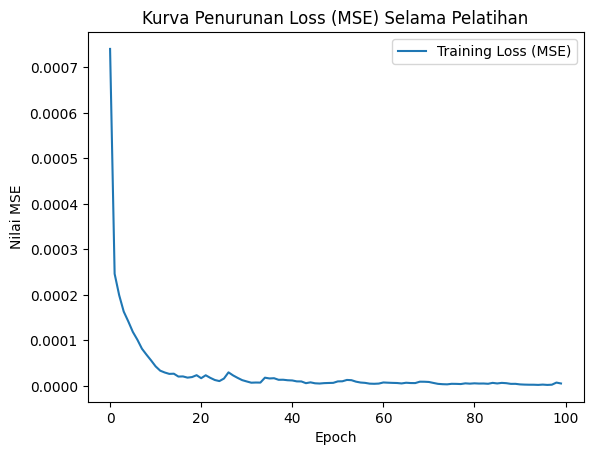

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.title('Kurva Penurunan Loss (MSE) Selama Pelatihan')
plt.xlabel('Epoch')
plt.ylabel('Nilai MSE')
plt.legend()

# === KODE UNTUK MENYIMPAN GAMBAR ===
plt.savefig('kurva mse.png', dpi=300, bbox_inches='tight')
plt.show()

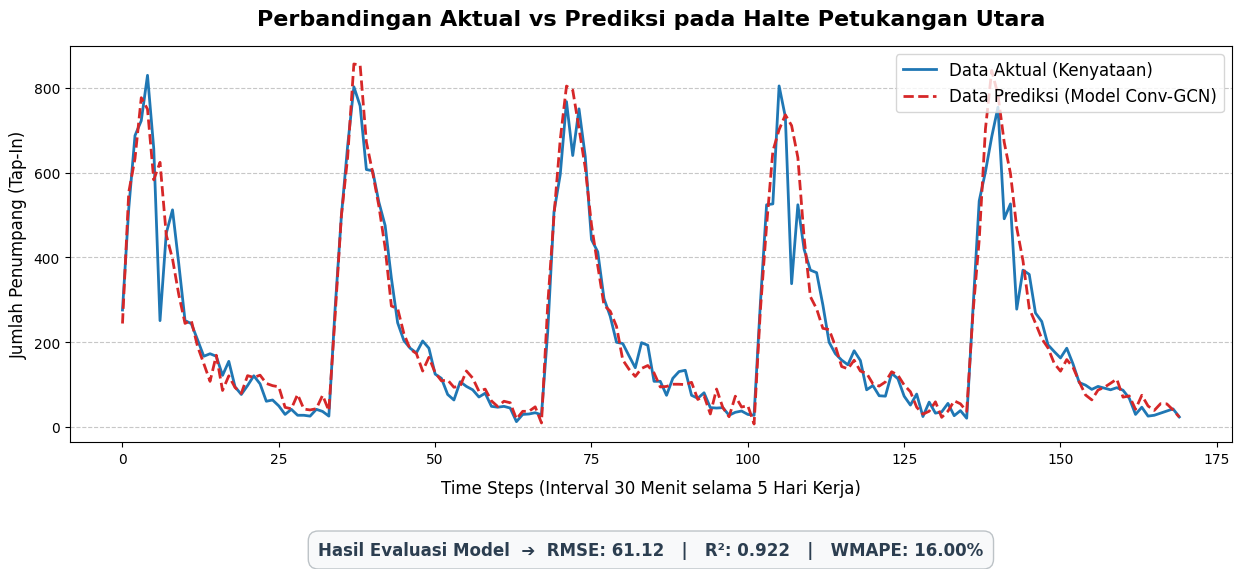

In [10]:
import matplotlib.pyplot as plt
import numpy as np

halte_idx = 150 
nama_halte = f"Halte Index {halte_idx} (Top 1 Busiest)"

# --- 1. PERSIAPAN DATA & PERHITUNGAN METRIK ---
actual = Y_te_orig[:, halte_idx]
predicted = y_pred_denorm_final[:, halte_idx]

# Hitung metrik
rmse = np.sqrt(np.mean((actual - predicted)**2))
ss_res = np.sum((actual - predicted)**2)
ss_tot = np.sum((actual - np.mean(actual))**2)
rsq = 1 - (ss_res / ss_tot)
wmape = np.sum(np.abs(actual - predicted)) / np.sum(np.abs(actual))

# Format teks metrik dibuat horizontal (satu baris mendatar)
metrics_text = f"Hasil Evaluasi Model  ➔  RMSE: {rmse:.2f}   |   R²: {rsq:.3f}   |   WMAPE: {wmape:.2%}"

# --- 2. PROSES PLOTTING ---
plt.figure(figsize=(15, 6))

# Plot Garis Aktual dan Prediksi
plt.plot(actual, label='Data Aktual (Kenyataan)', color='#1f77b4', linewidth=2)
plt.plot(predicted, label='Data Prediksi (Model Conv-GCN)', color='#d62728', linewidth=2, linestyle='--')

plt.title(f"Perbandingan Aktual vs Prediksi pada Halte Petukangan Utara", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Time Steps (Interval 30 Menit selama 5 Hari Kerja)", fontsize=12, labelpad=10)
plt.ylabel("Jumlah Penumpang (Tap-In)", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right', fontsize=12)

# --- 3. MENEMPATKAN KOTAK METRIK DI BAWAH GRAFIK ---
ax = plt.gca()
ax.text(
    0.5, -0.25,            # X=0.5 (tengah grafik), Y=-0.25 (di bawah label X)
    metrics_text,
    transform=ax.transAxes,
    fontsize=12,
    fontweight='bold',
    color='#2c3e50',
    horizontalalignment='center', # Teks rata tengah
    verticalalignment='top',      # Titik acuan dari atas kotak teks
    bbox=dict(
        boxstyle='round,pad=0.6',
        facecolor='#f8f9fa',      # Warna background abu-abu sangat muda/bersih
        alpha=1.0,
        edgecolor='#bdc3c7',      # Warna border kotak
        linewidth=1
    )
)

# Memberikan ruang tambahan di bagian bawah canvas agar kotak teks tidak terpotong
plt.subplots_adjust(bottom=0.22)

# === KODE UNTUK MENYIMPAN GAMBAR ===
plt.savefig('Perbandingan_aktual_prediksi_metrik_petukangan_utara.png', dpi=300, bbox_inches='tight')
plt.show()

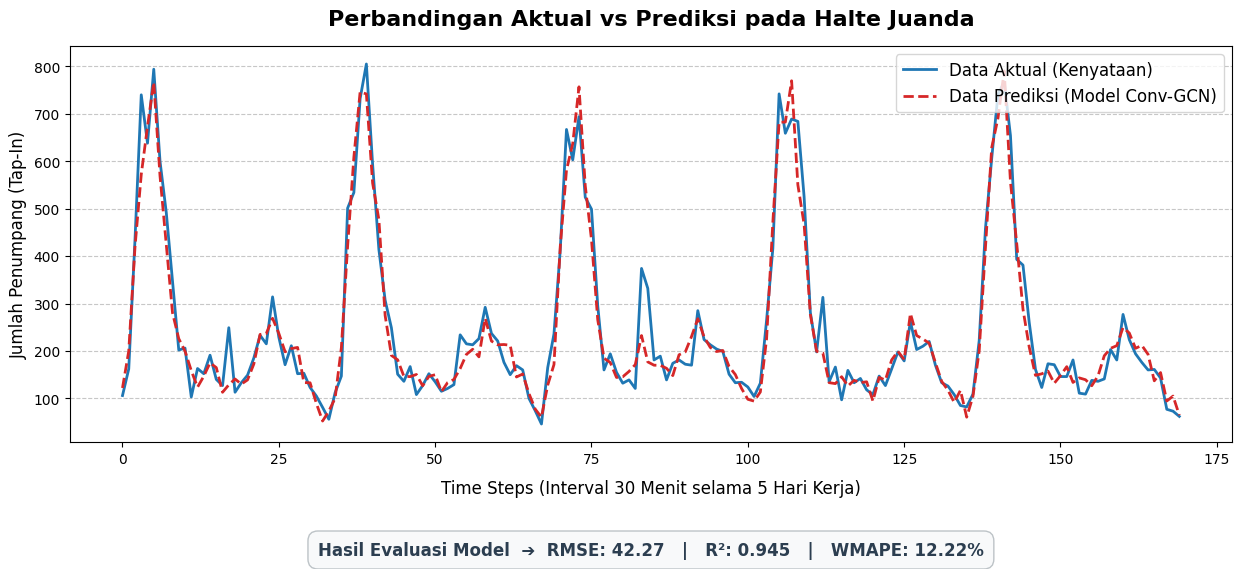

In [11]:
import matplotlib.pyplot as plt
import numpy as np

halte_idx = 71 
nama_halte = f"Halte Index {halte_idx} (Top 1 Busiest)"

# --- 1. PERSIAPAN DATA & PERHITUNGAN METRIK ---
actual = Y_te_orig[:, halte_idx]
predicted = y_pred_denorm_final[:, halte_idx]

# Hitung metrik
rmse = np.sqrt(np.mean((actual - predicted)**2))
ss_res = np.sum((actual - predicted)**2)
ss_tot = np.sum((actual - np.mean(actual))**2)
rsq = 1 - (ss_res / ss_tot)
wmape = np.sum(np.abs(actual - predicted)) / np.sum(np.abs(actual))

# Format teks metrik dibuat horizontal (satu baris mendatar)
metrics_text = f"Hasil Evaluasi Model  ➔  RMSE: {rmse:.2f}   |   R²: {rsq:.3f}   |   WMAPE: {wmape:.2%}"

# --- 2. PROSES PLOTTING ---
plt.figure(figsize=(15, 6))

# Plot Garis Aktual dan Prediksi
plt.plot(actual, label='Data Aktual (Kenyataan)', color='#1f77b4', linewidth=2)
plt.plot(predicted, label='Data Prediksi (Model Conv-GCN)', color='#d62728', linewidth=2, linestyle='--')

plt.title(f"Perbandingan Aktual vs Prediksi pada Halte Juanda", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Time Steps (Interval 30 Menit selama 5 Hari Kerja)", fontsize=12, labelpad=10)
plt.ylabel("Jumlah Penumpang (Tap-In)", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right', fontsize=12)

# --- 3. MENEMPATKAN KOTAK METRIK DI BAWAH GRAFIK ---
ax = plt.gca()
ax.text(
    0.5, -0.25,            # X=0.5 (tengah grafik), Y=-0.25 (di bawah label X)
    metrics_text,
    transform=ax.transAxes,
    fontsize=12,
    fontweight='bold',
    color='#2c3e50',
    horizontalalignment='center', # Teks rata tengah
    verticalalignment='top',      # Titik acuan dari atas kotak teks
    bbox=dict(
        boxstyle='round,pad=0.6',
        facecolor='#f8f9fa',      # Warna background abu-abu sangat muda/bersih
        alpha=1.0,
        edgecolor='#bdc3c7',      # Warna border kotak
        linewidth=1
    )
)

# Memberikan ruang tambahan di bagian bawah canvas agar kotak teks tidak terpotong
plt.subplots_adjust(bottom=0.22)

# === KODE UNTUK MENYIMPAN GAMBAR ===
plt.savefig('Perbandingan_aktual_prediksi_metrik_juanda.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
import pandas as pd
# LOAD DATA TAP-IN & TAP-OUT (INTERVAL TERBAIK = 30 MENIT)
file_tapout = '/kaggle/input/datasets/elizarahmadania/plot-titik-lon-lat/(1) 40 HARI TAPOUT 30 MENIT.xlsx'
file_tapin = '/kaggle/input/datasets/elizarahmadania/plot-titik-lon-lat/(1) 40 HARI TAP IN 30 MENIT.xlsx' 
df_out = pd.read_excel(file_tapout)
df_in = pd.read_excel(file_tapin)
# MENGHITUNG TOTAL ARUS KE SAMPING (BARIS)
df_in['total_tapin'] = df_in.iloc[:, 4:].sum(axis=1)
df_out['total_tapout'] = df_out.iloc[:, 4:].sum(axis=1)
df_in_simple = df_in[['Nama Halte', 'stop_lat', 'stop_lon', 'total_tapin']]
df_out_simple = df_out[['Nama Halte', 'stop_lat', 'stop_lon', 'total_tapout']]
# GABUNGKAN (MERGE) KEDUA FILE
df_gabungan = pd.merge(
    df_in_simple, 
    df_out_simple, 
    on=['Nama Halte', 'stop_lat', 'stop_lon'], 
    how='outer'
)
df_gabungan['total_tapin'] = df_gabungan['total_tapin'].fillna(0)
df_gabungan['total_tapout'] = df_gabungan['total_tapout'].fillna(0)
# HITUNG TOTAL ARUS KESELURUHAN
df_gabungan['total_arus'] = df_gabungan['total_tapin'] + df_gabungan['total_tapout']

# URUTKAN BERDASARKAN TOTAL ARUS TERBESAR -> TERKECIL
df_gabungan = df_gabungan.sort_values(by='total_arus', ascending=False).reset_index(drop=True)

print("=== HASIL TOTAL ARUS 40 HARI UNTUK PETA (URUT TERBESAR-TERKECIL) ===")
display(df_gabungan)

=== HASIL TOTAL ARUS 40 HARI UNTUK PETA (URUT TERBESAR-TERKECIL) ===


,Nama Halte,stop_lat,stop_lon,total_tapin,total_tapout,total_arus
0,Petukangan Utara,-6.225193,106.758180,334299,347809,682108
1,Juanda,-6.168048,106.830890,335464,302608,638072
2,CSW,-6.239869,106.798364,315709,297801,613510
3,Puri Beta 2,-6.230550,106.723717,274426,272293,546719
4,Kalideres,-6.154412,106.705500,324101,204829,528930
...,...,...,...,...,...,...
220,Walikota Jakarta Utara Arah Cililitan,-6.118845,106.893470,18075,2134,20209
221,Kali Grogol Arah P.Ranti,-6.159755,106.791453,12900,7222,20122
222,Buaran,-6.215132,106.917680,6096,6319,12415
223,Istiqlal,-6.172252,106.830930,6073,4428,10501


In [ ]:
import pandas as pd

# LOAD DATA TAP-IN & TAP-OUT (INTERVAL TERBAIK = 30 MENIT)
file_tapout = '/kaggle/input/datasets/elizarahmadania/plot-titik-lon-lat/(1) 40 HARI TAPOUT 30 MENIT.xlsx'
file_tapin = '/kaggle/input/datasets/elizarahmadania/plot-titik-lon-lat/(1) 40 HARI TAP IN 30 MENIT.xlsx' 
df_out = pd.read_excel(file_tapout)
df_in = pd.read_excel(file_tapin)

# MENGHITUNG TOTAL ARUS KE SAMPING (BARIS)
df_in['total_tapin'] = df_in.iloc[:, 4:].sum(axis=1)
df_out['total_tapout'] = df_out.iloc[:, 4:].sum(axis=1)

df_in_simple = df_in[['Nama Halte', 'stop_lat', 'stop_lon', 'total_tapin']]
df_out_simple = df_out[['Nama Halte', 'stop_lat', 'stop_lon', 'total_tapout']]

# GABUNGKAN (MERGE) KEDUA FILE
df_gabungan = pd.merge(
    df_in_simple, 
    df_out_simple, 
    on=['Nama Halte', 'stop_lat', 'stop_lon'], 
    how='outer'
)
df_gabungan['total_tapin'] = df_gabungan['total_tapin'].fillna(0)
df_gabungan['total_tapout'] = df_gabungan['total_tapout'].fillna(0)

# HITUNG TOTAL ARUS KESELURUHAN
df_gabungan['total_arus'] = df_gabungan['total_tapin'] + df_gabungan['total_tapout']

# URUTKAN BERDASARKAN TOTAL ARUS TERBESAR -> TERKECIL
df_gabungan = df_gabungan.sort_values(by='total_arus', ascending=False).reset_index(drop=True)

# =======================================================
# AMBIL TOP 10 HALTE TERPADAT
# =======================================================
top_10_halte = df_gabungan.head(10)

print("=== TOP 10 HALTE DENGAN TOTAL ARUS TERPADAT (40 HARI) ===")
display(top_10_halte)

In [ ]:
import folium
from folium.plugins import HeatMap

# Inisialisasi peta Jakarta (koordinat tengah Jakarta)
map_jakarta = folium.Map(location=[-6.2088, 106.8456], zoom_start=12, tiles='CartoDB positron')

# Menambahkan Bubble Marker ke Peta
for index, row in df_gabungan.iterrows():
    radius_size = row['total_arus'] / 60000 
    
    # lingkaran untuk setiap halte
    folium.CircleMarker(
        location=[row['stop_lat'], row['stop_lon']],
        radius=radius_size if radius_size > 2 else 2, # Minimal radius 2 agar tetap kelihatan
        popup=f"Halte: {row['Nama Halte']}<br>Total Penumpang: {row['total_arus']:,}",
        tooltip=row['Nama Halte'],
        color='red', # Warna garis pinggir
        fill=True,
        fill_color='#FF0000', # Warna isi lingkaran
        fill_opacity=0.6
    ).add_to(map_jakarta)

# =====================================================================
# TAMBAHKAN BARIS INI UNTUK MENYIMPAN KE FILE HTML
# =====================================================================
nama_file_html = 'peta_arus_penumpang_interaktif.html'
map_jakarta.save(nama_file_html)
print(f"Peta berhasil disimpan dengan nama: {nama_file_html}")

# Tetap tampilkan peta di dalam notebook
map_jakarta

In [ ]:

import folium
from folium.plugins import HeatMap

# =====================================================================
# 1. DEKLARASI DATA MAPPING
# =====================================================================
data_mapping = [
    ('Blok M', 'Koridor 1'), ('CSW', 'Koridor 1'), ('ASEAN', 'Koridor 1'),
    ('Kejaksaan Agung', 'Koridor 1'), ('Masjid Agung', 'Koridor 1'),
    ('Bundaran Senayan', 'Koridor 1'), ('Senayan Bank Jakarta', 'Koridor 1'),
    ('Polda Metro Jaya', 'Koridor 1'), ('Bendungan Hilir', 'Koridor 1'),
    ('Karet', 'Koridor 1'), ('Dukuh Atas', 'Koridor 1'), ('Tosari', 'Koridor 1'),
    ('Bundaran HI Astra', 'Koridor 1'), ('MH Thamrin', 'Koridor 1'),
    ('Kebon Sirih Arah Blok M', 'Koridor 1'), ('Kebon Sirih Arah Kota', 'Koridor 1'),
    ('Monumen Nasional', 'Koridor 1'), ('Harmoni Arah Blok M', 'Koridor 1'),
    ('Sawah Besar Arah Blok M', 'Koridor 1'), ('Taman Sari', 'Koridor 1'),
    ('Glodok', 'Koridor 1'), ('Kota', 'Koridor 1'), ('Kali Besar', 'Koridor 1'),
    ('Museum Sejarah Jakarta', 'Koridor 1'),
    ('Pulo Gadung', 'Koridor 2'), ('Bermis', 'Koridor 2'), ('Pulo Mas', 'Koridor 2'),
    ('Perintis Kemerdekaan', 'Koridor 2'), ('Pedongkelan', 'Koridor 2'),
    ('Cempaka Mas', 'Koridor 2'), ('Sumur Batu', 'Koridor 2'),
    ('Cempaka Baru', 'Koridor 2'), ('Pasar Cempaka Putih', 'Koridor 2'),
    ('Rawa Selatan', 'Koridor 2'), ('Galur', 'Koridor 2'), ('Senen Raya', 'Koridor 2'),
    ('RSPAD', 'Koridor 2'), ('Pejambon', 'Koridor 2'), ('Gambir', 'Koridor 2'),
    ('Istiqlal', 'Koridor 2'), ('Juanda', 'Koridor 2'), ('Pecenongan', 'Koridor 2'),
    ('Monumen Nasional', 'Koridor 2'), ('Balai Kota', 'Koridor 2'), ('Gambir 2', 'Koridor 2'), 
    ('Kwitang', 'Koridor 2'),
    ('Monumen Nasional', 'Koridor 3'), ('Petojo', 'Koridor 3'), ('Roxy', 'Koridor 3'),
    ('Grogol', 'Koridor 3'), ('Jelambar', 'Koridor 3'), ('Damai', 'Koridor 3'),
    ('Taman Kota', 'Koridor 3'), ('Jembatan Gantung', 'Koridor 3'),
    ('Pulo Nangka', 'Koridor 3'), ('Jembatan Baru', 'Koridor 3'),
    ('Rawa Buaya', 'Koridor 3'), ('Sumur Bor', 'Koridor 3'), ('Pesakih', 'Koridor 3'),
    ('Kalideres', 'Koridor 3'),
    ('Pulo Gadung', 'Koridor 4'), ('Pasar Pulo Gadung', 'Koridor 4'),
    ('Pemuda Merdeka', 'Koridor 4'), ('Layur', 'Koridor 4'),
    ('Pemuda Rawamangun', 'Koridor 4'), ('Velodrome', 'Koridor 4'),
    ('Kayu Jati', 'Koridor 4'), ('Rawamangun', 'Koridor 4'),
    ('Pramuka Sari', 'Koridor 4'), ('Utan Kayu', 'Koridor 4'),
    ('Utan Kayu Rawamangun', 'Koridor 4'), ('Flyover Pramuka', 'Koridor 4'),
    ('Manggarai', 'Koridor 4'), ('Plaza Stasiun Manggarai', 'Koridor 4'),
    ('Pasar Rumput', 'Koridor 4'), ('Halimun', 'Koridor 4'), ('Galunggung', 'Koridor 4'),
    ('Ancol', 'Koridor 5'), ('Pademangan', 'Koridor 5'), ('Gunung Sahari', 'Koridor 5'),
    ('Jembatan Merah', 'Koridor 5'), ('Lapangan Banteng', 'Koridor 5'),
    ('Jaga Jakarta', 'Koridor 5'), ('Pal Putih', 'Koridor 5'),
    ('Kramat Sentiong', 'Koridor 5'), ('Salemba', 'Koridor 5'), ('Paseban', 'Koridor 5'),
    ('Matraman I', 'Koridor 5'), ('Tegalan', 'Koridor 5'), ('Matraman Baru', 'Koridor 5'),
    ('Bali Mester', 'Koridor 5'), ('Jatinegara', 'Koridor 5'), ('Kampung Melayu', 'Koridor 5'),
    ('Ragunan', 'Koridor 6'), ('Jati Barat', 'Koridor 6'), ('Jati Padang', 'Koridor 6'),
    ('Pejaten', 'Koridor 6'), ('Buncit Indah', 'Koridor 6'), ('Warung Jati', 'Koridor 6'),
    ('Warung Buncit', 'Koridor 6'), ('Duren Tiga', 'Koridor 6'),
    ('Mampang Prapatan', 'Koridor 6'), ('Underpass Kuningan', 'Koridor 6'),
    ('Patra Kuningan', 'Koridor 6'), ('Kuningan', 'Koridor 6'),
    ('Rasuna Said', 'Koridor 6'), ('Karet Kuningan', 'Koridor 6'),
    ('Kuningan Madya', 'Koridor 6'), ('Setiabudi', 'Koridor 6'),
    ('Halimun', 'Koridor 6'), ('Galunggung', 'Koridor 6'),
    ('Kampung Melayu', 'Koridor 7'), ('Bidara Cina', 'Koridor 7'),
    ('Gelanggang Remaja', 'Koridor 7'), ('Cawang Baru', 'Koridor 7'),
    ('BNN', 'Koridor 7'), ('Cawang Sentral', 'Koridor 7'),
    ('Cawang Cililitan', 'Koridor 7'), ('Cililitan', 'Koridor 7'),
    ('Trikora', 'Koridor 7'), ('Flyover Raya Bogor', 'Koridor 7'),
    ('Tanah Merdeka', 'Koridor 7'), ('Tanah Merdeka 2', 'Koridor 7'),
    ('Kampung Rambutan', 'Koridor 7'),
    ('Pasar Baru', 'Koridor 8'), ('Juanda', 'Koridor 8'), ('Pecenongan', 'Koridor 8'),
    ('Petojo', 'Koridor 8'), ('Tarakan', 'Koridor 8'), ('Tomang Raya', 'Koridor 8'),
    ('Tanjung Duren Arah P.Ranti', 'Koridor 8'), ('Tanjung Duren Arah Pluit', 'Koridor 8'),
    ('Grogol Reformasi', 'Koridor 8'), ('Jelambar', 'Koridor 8'), ('Damai', 'Koridor 8'), 
    ('Kedoya', 'Koridor 8'), ('Kedoya Panjang', 'Koridor 8'), ('Duri Kepa', 'Koridor 8'),
    ('Kebon Jeruk', 'Koridor 8'), ('Kelapa Dua Sasak', 'Koridor 8'),
    ('Pos Pengumben', 'Koridor 8'), ('Arteri', 'Koridor 8'), ('Permata Hijau', 'Koridor 8'),
    ('Simprug', 'Koridor 8'), ('Kebayoran', 'Koridor 8'), ('Bungur', 'Koridor 8'),
    ('Tanah Kusir', 'Koridor 8'), ('Pondok Indah', 'Koridor 8'),
    ('Underpass Lebak Bulus', 'Koridor 8'), ('Pondok Pinang', 'Koridor 8'),
    ('Lebak Bulus', 'Koridor 8'),
    ('Jembatan Tiga', 'Koridor 9'), ('Jembatan Dua', 'Koridor 9'),
    ('Jembatan Besi', 'Koridor 9'), ('Kali Grogol Arah P.Ranti', 'Koridor 9'),
    ('Kali Grogol Arah Pluit', 'Koridor 9'), ('Grogol Reformasi', 'Koridor 9'),
    ('Tanjung Duren Arah P.Ranti', 'Koridor 9'), ('Tanjung Duren Arah Pluit', 'Koridor 9'),
    ('Kota Bambu Arah Pluit', 'Koridor 9'), ('Kota Bambu Arah P.Ranti', 'Koridor 9'),
    ('Kemanggisan Arah P.Ranti', 'Koridor 9'), ('Kemanggisan Arah Pluit', 'Koridor 9'),
    ('Petamburan', 'Koridor 9'), ('Gerbang Pemuda Arah P.Ranti', 'Koridor 9'),
    ('Gerbang Pemuda Arah Pluit', 'Koridor 9'), ('Semanggi', 'Koridor 9'),
    ('Widya Chandra Telkomsel Arah P.Ranti', 'Koridor 9'),
    ('Widya Chandra Telkomsel Arah Pluit', 'Koridor 9'),
    ('Denpasar Arah P.Ranti (Jamsostek)', 'Koridor 9'),
    ('Denpasar Arah Pluit (Jamsostek)', 'Koridor 9'),
    ('Tegal Parang Arah P.Ranti', 'Koridor 9'), ('Tegal Parang Arah Pluit', 'Koridor 9'),
    ('Pancoran Arah P.Ranti', 'Koridor 9'), ('Pancoran Arah Pluit', 'Koridor 9'),
    ('Pancoran Tugu', 'Koridor 9'), ('Tebet Eco Park Arah P.Ranti', 'Koridor 9'),
    ('Tebet Eco Park Arah Pluit', 'Koridor 9'), ('Cikoko Arah P.Ranti', 'Koridor 9'),
    ('Cikoko Arah Pluit', 'Koridor 9'), ('Ciliwung Arah P.Ranti', 'Koridor 9'),
    ('Ciliwung Arah Pluit', 'Koridor 9'), ('BNN', 'Koridor 9'), ('Cawang Sentral', 'Koridor 9'), 
    ('Makasar', 'Koridor 9'), ('Pinang Ranti', 'Koridor 9'),
    ('Koja', 'Koridor 10'), ('Walikota Jakarta Utara Arah Cililitan', 'Koridor 10'),
    ('Walikota Jakarta Utara Arah Tj. Priuk', 'Koridor 10'), ('Plumpang', 'Koridor 10'),
    ('Sunter Kelapa Gading', 'Koridor 10'), ('Kodamar', 'Koridor 10'),
    ('Cempaka Putih', 'Koridor 10'), ('Pulo Mas Bypass', 'Koridor 10'),
    ('Kayu Putih Rawasari', 'Koridor 10'), ('Utan Kayu Rawamangun', 'Koridor 10'),
    ('Flyover Jatinegara', 'Koridor 10'), ('Pedati Prumpung', 'Koridor 10'),
    ('Kebon Nanas', 'Koridor 10'), ('Halim', 'Koridor 10'), ('Simpang Cawang', 'Koridor 10'),
    ('Cawang Sentral', 'Koridor 10'), ('Cawang Cililitan', 'Koridor 10'), ('PGC', 'Koridor 10'),
    ('Pulo Gebang', 'Koridor 11'), ('Walikota Jakarta Timur', 'Koridor 11'),
    ('Penggilingan', 'Koridor 11'), ('Flyover Pondok Kopi', 'Koridor 11'),
    ('Buaran', 'Koridor 11'), ('Kampung Sumur', 'Koridor 11'), ('Klender', 'Koridor 11'),
    ('Stasiun Klender', 'Koridor 11'), ('Cipinang', 'Koridor 11'),
    ('Flyover Cipinang', 'Koridor 11'), ('Pasar Enjo', 'Koridor 11'),
    ('Flyover Jatinegara', 'Koridor 11'), ('Stasiun Jatinegara', 'Koridor 11'), 
    ('Jatinegara', 'Koridor 11'), ('Kampung Melayu', 'Koridor 11'),
    ('Pluit', 'Koridor 12'), ('Pluit Selatan', 'Koridor 12'), ('Pakin', 'Koridor 12'),
    ('Gedong Panjang', 'Koridor 12'), ('Museum Sejarah Jakarta', 'Koridor 12'), 
    ('Kota', 'Koridor 12'), ('Mangga Dua Raya', 'Koridor 12'), ('Mangga Dua', 'Koridor 12'),
    ('Gunung Sahari', 'Koridor 12'), ('Jembatan Merah', 'Koridor 12'), 
    ('Landasan Pacu', 'Koridor 12'), ('Danau Agung', 'Koridor 12'),
    ('Danau Sunter', 'Koridor 12'), ('Sunter Utara', 'Koridor 12'),
    ('Sunter Karya', 'Koridor 12'), ('Sunter Boulevard Barat', 'Koridor 12'),
    ('Sunter Kelapa Gading', 'Koridor 12'), ('Plumpang', 'Koridor 12'),
    ('Walikota Jakarta Timur', 'Koridor 12'), ('Koja', 'Koridor 12'), 
    ('Penjaringan', 'Koridor 12'), ('Kali Besar', 'Koridor 12'),
    ('Puri Beta 2', 'Koridor 13'), ('Petukangan Utara', 'Koridor 13'),
    ('JORR', 'Koridor 13'), ('Swadarma', 'Koridor 13'), ('Cipulir', 'Koridor 13'),
    ('Seskoal', 'Koridor 13'), ('Kebayoran Lama', 'Koridor 13'), ('Velbak', 'Koridor 13'),
    ('Mayestik', 'Koridor 13'), ('CSW', 'Koridor 13'), ('ASEAN', 'Koridor 13'), 
    ('Kejaksaan Agung', 'Koridor 13'), ('Pasar Santa', 'Koridor 13'),
    ('Rawa Barat', 'Koridor 13'), ('Tegal Mampang', 'Koridor 13'),
    ('Jembatan Item', 'Koridor 14'), ('Danau Sunter', 'Koridor 14'), ('Danau Agung', 'Koridor 14'),
    ('Landasan Pacu', 'Koridor 14'), ('Kemayoran', 'Koridor 14'), ('Tanah Tinggi', 'Koridor 14'), 
    ('Senen Raya', 'Koridor 14')
]

# =====================================================================
# 2. PRE-PROCESSING DATA UNTUK MAPPING KORIDOR & JALUR
# =====================================================================
halte_coords = {}
for index, row in df_gabungan.iterrows():
    nama_clean = str(row['Nama Halte']).upper().strip()
    halte_coords[nama_clean] = (row['stop_lat'], row['stop_lon'])

corridor_routes = {}
halte_to_corridors = {}

for halte, corridor in data_mapping:
    halte_clean = str(halte).upper().strip()
    
    if corridor not in corridor_routes:
        corridor_routes[corridor] = []
    if halte_clean in halte_coords:
        corridor_routes[corridor].append(halte_coords[halte_clean])
        
    if halte_clean not in halte_to_corridors:
        halte_to_corridors[halte_clean] = []
    if corridor not in halte_to_corridors[halte_clean]:
        halte_to_corridors[halte_clean].append(corridor)


# =====================================================================
# 3. INISIALISASI PETA JAKARTA
# =====================================================================
map_jakarta = folium.Map(location=[-6.2088, 106.8456], zoom_start=12, tiles='CartoDB positron')


# =====================================================================
# 4. FUNGSI UNTUK SLUGIFY NAMA HALTE (CLEANING)
# =====================================================================
import re

def slugify(text):
    """Mengubah teks menjadi format yang aman untuk CSS class"""
    text = str(text).lower().strip()
    text = re.sub(r'[^\w\s-]', '', text)  # Hapus karakter spesial
    text = re.sub(r'[\s_]+', '-', text)   # Ganti spasi/underscore dengan dash
    return text


# =====================================================================
# 5. BUAT GARIS KORIDOR LENGKAP (PER HALTE + PER KORIDOR)
# =====================================================================
# Simpan kombinasi (halte_slug, corridor_slug) yang sudah dibuat untuk menghindari duplikat
created_routes = set()

for index, row in df_gabungan.iterrows():
    nama_halte = row['Nama Halte']
    nama_clean = str(nama_halte).upper().strip()
    halte_slug = slugify(nama_halte)
    
    # Dapatkan list koridor yang dilalui halte ini
    list_koridor = halte_to_corridors.get(nama_clean, [])
    
    # Untuk setiap koridor yang dilalui halte, buat garis koridor lengkap
    for corridor in list_koridor:
        corridor_slug = slugify(corridor)
        route_key = (halte_slug, corridor_slug)
        
        # Skip jika sudah pernah dibuat (hindari duplikasi)
        if route_key in created_routes:
            continue
        
        # Ambil koordinat halte-halte dalam koridor ini
        if corridor in corridor_routes and len(corridor_routes[corridor]) > 1:
            coords = corridor_routes[corridor]
            
            # Buat satu garis panjang untuk seluruh koridor
            folium.PolyLine(
                locations=coords,
                color='#007BFF',
                weight=4,
                opacity=0,  # Awalnya tersembunyi
                className=f'route-{halte_slug}-{corridor_slug}',  # Class: halte-koridor
                control=False
            ).add_to(map_jakarta)
            
            created_routes.add(route_key)


# =====================================================================
# 6. MENAMBAHKAN BUBBLE MARKER HALTE
# =====================================================================
for index, row in df_gabungan.iterrows():
    radius_size = row['total_arus'] / 40000 
    nama_halte = row['Nama Halte']
    nama_clean = str(nama_halte).upper().strip()
    halte_slug = slugify(nama_halte)
    
    list_koridor = halte_to_corridors.get(nama_clean, [])
    koridor_text = ", ".join(list_koridor) if list_koridor else "Tidak Termapping"
    
    popup_content = f"""
    <div class="stop-popup" data-halte-slug="{halte_slug}">
        <h4 style="margin:0 0 5px 0; color:#333;">{nama_halte}</h4>
        <p style="margin:0 0 5px 0;"><b>Total Penumpang:</b> {row['total_arus']:,}</p>
        <p style="margin:0; font-size:11px; color:#007BFF;"><b>Jalur:</b> {koridor_text}</p>
    </div>
    """
    
    folium.CircleMarker(
        location=[row['stop_lat'], row['stop_lon']],
        radius=radius_size if radius_size > 2 else 2,
        popup=folium.Popup(popup_content, max_width=250),
        tooltip=nama_halte,
        color='red',
        fill=True,
        fill_color='#FF0000',
        fill_opacity=0.6
    ).add_to(map_jakarta)


# =====================================================================
# 7. SUNTIK JAVASCRIPT UNTUK TOGGLE GARIS KORIDOR LENGKAP
# =====================================================================
map_js_name = map_jakarta.get_name()

js_script = f"""
<script>
(function() {{
    function checkMap() {{
        if (typeof {map_js_name} !== 'undefined') {{
            var mapObject = {map_js_name};
            
            // Trigger saat HALTE DIKLIK (popup dibuka)
            mapObject.on('popupopen', function(e) {{
                // Pastikan semua garis sembunyi terlebih dahulu
                var allRoutes = document.querySelectorAll('[class*="route-"]');
                allRoutes.forEach(function(route) {{
                    route.setAttribute('stroke-opacity', '0');
                }});
                
                // Ambil data halte dari popup
                var popupNode = e.popup._contentNode;
                var container = popupNode.querySelector('.stop-popup');
                
                if (container) {{
                    var halteSlug = container.getAttribute('data-halte-slug');
                    
                    // Tampilkan garis-garis koridor yang dilalui halte ini
                    // Cari semua garis yang dimulai dengan 'route-{halte_slug}-'
                    var routesForHalte = document.querySelectorAll('[class*="route-' + halteSlug + '-"]');
                    routesForHalte.forEach(function(route) {{
                        route.setAttribute('stroke-opacity', '0.85');
                        // Naikkan layer ke paling atas agar terlihat
                        if (route.parentNode) {{
                            route.parentNode.appendChild(route);
                        }}
                    }});
                    
                    console.log('Menampilkan ' + routesForHalte.length + ' koridor untuk halte: ' + halteSlug);
                }}
            }});
            
            // Trigger saat POPUP DITUTUP
            mapObject.on('popupclose', function(e) {{
                var allRoutes = document.querySelectorAll('[class*="route-"]');
                allRoutes.forEach(function(route) {{
                    route.setAttribute('stroke-opacity', '0');
                }});
                console.log('Semua garis disembunyikan');
            }});
            
        }} else {{
            setTimeout(checkMap, 100);
        }}
    }}
    checkMap();
}})();
</script>
"""

map_jakarta.get_root().html.add_child(folium.Element(js_script))


# =====================================================================
# 8. SIMPAN DAN TAMPILKAN PETA
# =====================================================================
nama_file_html = 'peta_penumpang_interaktif.html'
map_jakarta.save(nama_file_html)
print(f"Peta interaktif berhasil disimpan dengan nama: {nama_file_html}")

map_jakarta

In [ ]:
import folium
from folium.plugins import HeatMap

# =====================================================================
# 1. DEKLARASI DATA MAPPING
# =====================================================================
data_mapping = [
    ('Blok M', 'Koridor 1'), ('CSW', 'Koridor 1'), ('ASEAN', 'Koridor 1'),
    ('Kejaksaan Agung', 'Koridor 1'), ('Masjid Agung', 'Koridor 1'),
    ('Bundaran Senayan', 'Koridor 1'), ('Senayan Bank Jakarta', 'Koridor 1'),
    ('Polda Metro Jaya', 'Koridor 1'), ('Bendungan Hilir', 'Koridor 1'),
    ('Karet', 'Koridor 1'), ('Dukuh Atas', 'Koridor 1'), ('Tosari', 'Koridor 1'),
    ('Bundaran HI Astra', 'Koridor 1'), ('MH Thamrin', 'Koridor 1'),
    ('Kebon Sirih Arah Blok M', 'Koridor 1'), ('Kebon Sirih Arah Kota', 'Koridor 1'),
    ('Monumen Nasional', 'Koridor 1'), ('Harmoni Arah Blok M', 'Koridor 1'),
    ('Sawah Besar Arah Blok M', 'Koridor 1'), ('Taman Sari', 'Koridor 1'),
    ('Glodok', 'Koridor 1'), ('Kota', 'Koridor 1'), ('Kali Besar', 'Koridor 1'),
    ('Museum Sejarah Jakarta', 'Koridor 1'),
    ('Pulo Gadung', 'Koridor 2'), ('Bermis', 'Koridor 2'), ('Pulo Mas', 'Koridor 2'),
    ('Perintis Kemerdekaan', 'Koridor 2'), ('Pedongkelan', 'Koridor 2'),
    ('Cempaka Mas', 'Koridor 2'), ('Sumur Batu', 'Koridor 2'),
    ('Cempaka Baru', 'Koridor 2'), ('Pasar Cempaka Putih', 'Koridor 2'),
    ('Rawa Selatan', 'Koridor 2'), ('Galur', 'Koridor 2'), ('Senen Raya', 'Koridor 2'),
    ('RSPAD', 'Koridor 2'), ('Pejambon', 'Koridor 2'), ('Gambir', 'Koridor 2'),
    ('Istiqlal', 'Koridor 2'), ('Juanda', 'Koridor 2'), ('Pecenongan', 'Koridor 2'),
    ('Monumen Nasional', 'Koridor 2'), ('Balai Kota', 'Koridor 2'), ('Gambir 2', 'Koridor 2'), 
    ('Kwitang', 'Koridor 2'),
    ('Monumen Nasional', 'Koridor 3'), ('Petojo', 'Koridor 3'), ('Roxy', 'Koridor 3'),
    ('Grogol', 'Koridor 3'), ('Jelambar', 'Koridor 3'), ('Damai', 'Koridor 3'),
    ('Taman Kota', 'Koridor 3'), ('Jembatan Gantung', 'Koridor 3'),
    ('Pulo Nangka', 'Koridor 3'), ('Jembatan Baru', 'Koridor 3'),
    ('Rawa Buaya', 'Koridor 3'), ('Sumur Bor', 'Koridor 3'), ('Pesakih', 'Koridor 3'),
    ('Kalideres', 'Koridor 3'),
    ('Pulo Gadung', 'Koridor 4'), ('Pasar Pulo Gadung', 'Koridor 4'),
    ('Pemuda Merdeka', 'Koridor 4'), ('Layur', 'Koridor 4'),
    ('Pemuda Rawamangun', 'Koridor 4'), ('Velodrome', 'Koridor 4'),
    ('Kayu Jati', 'Koridor 4'), ('Rawamangun', 'Koridor 4'),
    ('Pramuka Sari', 'Koridor 4'), ('Utan Kayu', 'Koridor 4'),
    ('Utan Kayu Rawamangun', 'Koridor 4'), ('Flyover Pramuka', 'Koridor 4'),
    ('Manggarai', 'Koridor 4'), ('Plaza Stasiun Manggarai', 'Koridor 4'),
    ('Pasar Rumput', 'Koridor 4'), ('Halimun', 'Koridor 4'), ('Galunggung', 'Koridor 4'),
    ('Ancol', 'Koridor 5'), ('Pademangan', 'Koridor 5'), ('Gunung Sahari', 'Koridor 5'),
    ('Jembatan Merah', 'Koridor 5'), ('Lapangan Banteng', 'Koridor 5'),
    ('Jaga Jakarta', 'Koridor 5'), ('Pal Putih', 'Koridor 5'),
    ('Kramat Sentiong', 'Koridor 5'), ('Salemba', 'Koridor 5'), ('Paseban', 'Koridor 5'),
    ('Matraman I', 'Koridor 5'), ('Tegalan', 'Koridor 5'), ('Matraman Baru', 'Koridor 5'),
    ('Bali Mester', 'Koridor 5'), ('Jatinegara', 'Koridor 5'), ('Kampung Melayu', 'Koridor 5'),
    ('Ragunan', 'Koridor 6'), ('Jati Barat', 'Koridor 6'), ('Jati Padang', 'Koridor 6'),
    ('Pejaten', 'Koridor 6'), ('Buncit Indah', 'Koridor 6'), ('Warung Jati', 'Koridor 6'),
    ('Warung Buncit', 'Koridor 6'), ('Duren Tiga', 'Koridor 6'),
    ('Mampang Prapatan', 'Koridor 6'), ('Underpass Kuningan', 'Koridor 6'),
    ('Patra Kuningan', 'Koridor 6'), ('Kuningan', 'Koridor 6'),
    ('Rasuna Said', 'Koridor 6'), ('Karet Kuningan', 'Koridor 6'),
    ('Kuningan Madya', 'Koridor 6'), ('Setiabudi', 'Koridor 6'),
    ('Halimun', 'Koridor 6'), ('Galunggung', 'Koridor 6'),
    ('Kampung Melayu', 'Koridor 7'), ('Bidara Cina', 'Koridor 7'),
    ('Gelanggang Remaja', 'Koridor 7'), ('Cawang Baru', 'Koridor 7'),
    ('BNN', 'Koridor 7'), ('Cawang Sentral', 'Koridor 7'),
    ('Cawang Cililitan', 'Koridor 7'), ('Cililitan', 'Koridor 7'),
    ('Trikora', 'Koridor 7'), ('Flyover Raya Bogor', 'Koridor 7'),
    ('Tanah Merdeka', 'Koridor 7'), ('Tanah Merdeka 2', 'Koridor 7'),
    ('Kampung Rambutan', 'Koridor 7'),
    ('Pasar Baru', 'Koridor 8'), ('Juanda', 'Koridor 8'), ('Pecenongan', 'Koridor 8'),
    ('Petojo', 'Koridor 8'), ('Tarakan', 'Koridor 8'), ('Tomang Raya', 'Koridor 8'),
    ('Tanjung Duren Arah P.Ranti', 'Koridor 8'), ('Tanjung Duren Arah Pluit', 'Koridor 8'),
    ('Grogol Reformasi', 'Koridor 8'), ('Jelambar', 'Koridor 8'), ('Damai', 'Koridor 8'), 
    ('Kedoya', 'Koridor 8'), ('Kedoya Panjang', 'Koridor 8'), ('Duri Kepa', 'Koridor 8'),
    ('Kebon Jeruk', 'Koridor 8'), ('Kelapa Dua Sasak', 'Koridor 8'),
    ('Pos Pengumben', 'Koridor 8'), ('Arteri', 'Koridor 8'), ('Permata Hijau', 'Koridor 8'),
    ('Simprug', 'Koridor 8'), ('Kebayoran', 'Koridor 8'), ('Bungur', 'Koridor 8'),
    ('Tanah Kusir', 'Koridor 8'), ('Pondok Indah', 'Koridor 8'),
    ('Underpass Lebak Bulus', 'Koridor 8'), ('Pondok Pinang', 'Koridor 8'),
    ('Lebak Bulus', 'Koridor 8'),
    ('Jembatan Tiga', 'Koridor 9'), ('Jembatan Dua', 'Koridor 9'),
    ('Jembatan Besi', 'Koridor 9'), ('Kali Grogol Arah P.Ranti', 'Koridor 9'),
    ('Kali Grogol Arah Pluit', 'Koridor 9'), ('Grogol Reformasi', 'Koridor 9'),
    ('Tanjung Duren Arah P.Ranti', 'Koridor 9'), ('Tanjung Duren Arah Pluit', 'Koridor 9'),
    ('Kota Bambu Arah Pluit', 'Koridor 9'), ('Kota Bambu Arah P.Ranti', 'Koridor 9'),
    ('Kemanggisan Arah P.Ranti', 'Koridor 9'), ('Kemanggisan Arah Pluit', 'Koridor 9'),
    ('Petamburan', 'Koridor 9'), ('Gerbang Pemuda Arah P.Ranti', 'Koridor 9'),
    ('Gerbang Pemuda Arah Pluit', 'Koridor 9'), ('Semanggi', 'Koridor 9'),
    ('Widya Chandra Telkomsel Arah P.Ranti', 'Koridor 9'),
    ('Widya Chandra Telkomsel Arah Pluit', 'Koridor 9'),
    ('Denpasar Arah P.Ranti (Jamsostek)', 'Koridor 9'),
    ('Denpasar Arah Pluit (Jamsostek)', 'Koridor 9'),
    ('Tegal Parang Arah P.Ranti', 'Koridor 9'), ('Tegal Parang Arah Pluit', 'Koridor 9'),
    ('Pancoran Arah P.Ranti', 'Koridor 9'), ('Pancoran Arah Pluit', 'Koridor 9'),
    ('Pancoran Tugu', 'Koridor 9'), ('Tebet Eco Park Arah P.Ranti', 'Koridor 9'),
    ('Tebet Eco Park Arah Pluit', 'Koridor 9'), ('Cikoko Arah P.Ranti', 'Koridor 9'),
    ('Cikoko Arah Pluit', 'Koridor 9'), ('Ciliwung Arah P.Ranti', 'Koridor 9'),
    ('Ciliwung Arah Pluit', 'Koridor 9'), ('BNN', 'Koridor 9'), ('Cawang Sentral', 'Koridor 9'), 
    ('Makasar', 'Koridor 9'), ('Pinang Ranti', 'Koridor 9'),
    ('Koja', 'Koridor 10'), ('Walikota Jakarta Utara Arah Cililitan', 'Koridor 10'),
    ('Walikota Jakarta Utara Arah Tj. Priuk', 'Koridor 10'), ('Plumpang', 'Koridor 10'),
    ('Sunter Kelapa Gading', 'Koridor 10'), ('Kodamar', 'Koridor 10'),
    ('Cempaka Putih', 'Koridor 10'), ('Pulo Mas Bypass', 'Koridor 10'),
    ('Kayu Putih Rawasari', 'Koridor 10'), ('Utan Kayu Rawamangun', 'Koridor 10'),
    ('Flyover Jatinegara', 'Koridor 10'), ('Pedati Prumpung', 'Koridor 10'),
    ('Kebon Nanas', 'Koridor 10'), ('Halim', 'Koridor 10'), ('Simpang Cawang', 'Koridor 10'),
    ('Cawang Sentral', 'Koridor 10'), ('Cawang Cililitan', 'Koridor 10'), ('PGC', 'Koridor 10'),
    ('Pulo Gebang', 'Koridor 11'), ('Walikota Jakarta Timur', 'Koridor 11'),
    ('Penggilingan', 'Koridor 11'), ('Flyover Pondok Kopi', 'Koridor 11'),
    ('Buaran', 'Koridor 11'), ('Kampung Sumur', 'Koridor 11'), ('Klender', 'Koridor 11'),
    ('Stasiun Klender', 'Koridor 11'), ('Cipinang', 'Koridor 11'),
    ('Flyover Cipinang', 'Koridor 11'), ('Pasar Enjo', 'Koridor 11'),
    ('Flyover Jatinegara', 'Koridor 11'), ('Stasiun Jatinegara', 'Koridor 11'), 
    ('Jatinegara', 'Koridor 11'), ('Kampung Melayu', 'Koridor 11'),
    ('Pluit', 'Koridor 12'), ('Pluit Selatan', 'Koridor 12'), ('Pakin', 'Koridor 12'),
    ('Gedong Panjang', 'Koridor 12'), ('Museum Sejarah Jakarta', 'Koridor 12'), 
    ('Kota', 'Koridor 12'), ('Mangga Dua Raya', 'Koridor 12'), ('Mangga Dua', 'Koridor 12'),
    ('Gunung Sahari', 'Koridor 12'), ('Jembatan Merah', 'Koridor 12'), 
    ('Landasan Pacu', 'Koridor 12'), ('Danau Agung', 'Koridor 12'),
    ('Danau Sunter', 'Koridor 12'), ('Sunter Utara', 'Koridor 12'),
    ('Sunter Karya', 'Koridor 12'), ('Sunter Boulevard Barat', 'Koridor 12'),
    ('Sunter Kelapa Gading', 'Koridor 12'), ('Plumpang', 'Koridor 12'),
    ('Walikota Jakarta Timur', 'Koridor 12'), ('Koja', 'Koridor 12'), 
    ('Penjaringan', 'Koridor 12'), ('Kali Besar', 'Koridor 12'),
    ('Puri Beta 2', 'Koridor 13'), ('Petukangan Utara', 'Koridor 13'),
    ('JORR', 'Koridor 13'), ('Swadarma', 'Koridor 13'), ('Cipulir', 'Koridor 13'),
    ('Seskoal', 'Koridor 13'), ('Kebayoran Lama', 'Koridor 13'), ('Velbak', 'Koridor 13'),
    ('Mayestik', 'Koridor 13'), ('CSW', 'Koridor 13'), ('ASEAN', 'Koridor 13'), 
    ('Kejaksaan Agung', 'Koridor 13'), ('Pasar Santa', 'Koridor 13'),
    ('Rawa Barat', 'Koridor 13'), ('Tegal Mampang', 'Koridor 13'),
    ('Jembatan Item', 'Koridor 14'), ('Danau Sunter', 'Koridor 14'), ('Danau Agung', 'Koridor 14'),
    ('Landasan Pacu', 'Koridor 14'), ('Kemayoran', 'Koridor 14'), ('Tanah Tinggi', 'Koridor 14'), 
    ('Senen Raya', 'Koridor 14')
]

# =====================================================================
# 2. PRE-PROCESSING DATA UNTUK MAPPING KORIDOR & JALUR
# =====================================================================
halte_coords = {}
for index, row in df_gabungan.iterrows():
    nama_clean = str(row['Nama Halte']).upper().strip()
    halte_coords[nama_clean] = (row['stop_lat'], row['stop_lon'])

corridor_routes = {}
halte_to_corridors = {}

for halte, corridor in data_mapping:
    halte_clean = str(halte).upper().strip()
    
    if corridor not in corridor_routes:
        corridor_routes[corridor] = []
    if halte_clean in halte_coords:
        corridor_routes[corridor].append(halte_coords[halte_clean])
        
    if halte_clean not in halte_to_corridors:
        halte_to_corridors[halte_clean] = []
    if corridor not in halte_to_corridors[halte_clean]:
        halte_to_corridors[halte_clean].append(corridor)


# =====================================================================
# 3. INISIALISASI PETA JAKARTA
# =====================================================================
map_jakarta = folium.Map(location=[-6.2088, 106.8456], zoom_start=12, tiles='CartoDB positron')


# =====================================================================
# 4. FUNGSI UNTUK SLUGIFY NAMA HALTE (CLEANING)
# =====================================================================
import re

def slugify(text):
    """Mengubah teks menjadi format yang aman untuk CSS class"""
    text = str(text).lower().strip()
    text = re.sub(r'[^\w\s-]', '', text)  # Hapus karakter spesial
    text = re.sub(r'[\s_]+', '-', text)   # Ganti spasi/underscore dengan dash
    return text


# =====================================================================
# 5. BUAT GARIS KORIDOR LENGKAP (PER HALTE + PER KORIDOR)
# =====================================================================
# Simpan kombinasi (halte_slug, corridor_slug) yang sudah dibuat untuk menghindari duplikat
created_routes = set()

for index, row in df_gabungan.iterrows():
    nama_halte = row['Nama Halte']
    nama_clean = str(nama_halte).upper().strip()
    halte_slug = slugify(nama_halte)
    
    # Dapatkan list koridor yang dilalui halte ini
    list_koridor = halte_to_corridors.get(nama_clean, [])
    
    # Untuk setiap koridor yang dilalui halte, buat garis koridor lengkap
    for corridor in list_koridor:
        corridor_slug = slugify(corridor)
        route_key = (halte_slug, corridor_slug)
        
        # Skip jika sudah pernah dibuat (hindari duplikasi)
        if route_key in created_routes:
            continue
        
        # Ambil koordinat halte-halte dalam koridor ini
        if corridor in corridor_routes and len(corridor_routes[corridor]) > 1:
            coords = corridor_routes[corridor]
            
            # Buat satu garis panjang untuk seluruh koridor
            folium.PolyLine(
                locations=coords,
                color='#FF0000',  # Merah, sesuai warna bubble
                weight=4,
                opacity=0,  # Awalnya tersembunyi
                className=f'route-{halte_slug}-{corridor_slug}',  # Class: halte-koridor
                control=False
            ).add_to(map_jakarta)
            
            created_routes.add(route_key)


# =====================================================================
# 6. MENAMBAHKAN BUBBLE MARKER HALTE
# =====================================================================
for index, row in df_gabungan.iterrows():
    radius_size = row['total_arus'] / 60000 
    nama_halte = row['Nama Halte']
    nama_clean = str(nama_halte).upper().strip()
    halte_slug = slugify(nama_halte)
    
    list_koridor = halte_to_corridors.get(nama_clean, [])
    koridor_text = ", ".join(list_koridor) if list_koridor else "Tidak Termapping"
    
    popup_content = f"""
    <div class="stop-popup" data-halte-slug="{halte_slug}">
        <h4 style="margin:0 0 5px 0; color:#333;">{nama_halte}</h4>
        <p style="margin:0 0 5px 0;"><b>Total Arus:</b> {row['total_arus']:,}</p>
        <p style="margin:0; font-size:11px; color:#007BFF;"><b>Jalur:</b> {koridor_text}</p>
    </div>
    """
    
    folium.CircleMarker(
        location=[row['stop_lat'], row['stop_lon']],
        radius=radius_size if radius_size > 2 else 2,
        popup=folium.Popup(popup_content, max_width=250),
        tooltip=nama_halte,
        color='red',
        fill=True,
        fill_color='#FF0000',
        fill_opacity=0.6
    ).add_to(map_jakarta)


# =====================================================================
# 7. SUNTIK JAVASCRIPT UNTUK TOGGLE GARIS KORIDOR LENGKAP
# =====================================================================
map_js_name = map_jakarta.get_name()

js_script = f"""
<script>
(function() {{
    function checkMap() {{
        if (typeof {map_js_name} !== 'undefined') {{
            var mapObject = {map_js_name};
            
            // Trigger saat HALTE DIKLIK (popup dibuka)
            mapObject.on('popupopen', function(e) {{
                // Pastikan semua garis sembunyi terlebih dahulu
                var allRoutes = document.querySelectorAll('[class*="route-"]');
                allRoutes.forEach(function(route) {{
                    route.setAttribute('stroke-opacity', '0');
                }});
                
                // Ambil data halte dari popup
                var popupNode = e.popup._contentNode;
                var container = popupNode.querySelector('.stop-popup');
                
                if (container) {{
                    var halteSlug = container.getAttribute('data-halte-slug');
                    
                    // Tampilkan garis-garis koridor yang dilalui halte ini
                    // Cari semua garis yang dimulai dengan 'route-{halte_slug}-'
                    var routesForHalte = document.querySelectorAll('[class*="route-' + halteSlug + '-"]');
                    routesForHalte.forEach(function(route) {{
                        route.setAttribute('stroke-opacity', '0.85');
                        // Naikkan layer ke paling atas agar terlihat
                        if (route.parentNode) {{
                            route.parentNode.appendChild(route);
                        }}
                    }});
                    
                    console.log('Menampilkan ' + routesForHalte.length + ' koridor untuk halte: ' + halteSlug);
                }}
            }});
            
            // Trigger saat POPUP DITUTUP
            mapObject.on('popupclose', function(e) {{
                var allRoutes = document.querySelectorAll('[class*="route-"]');
                allRoutes.forEach(function(route) {{
                    route.setAttribute('stroke-opacity', '0');
                }});
                console.log('Semua garis disembunyikan');
            }});
            
        }} else {{
            setTimeout(checkMap, 100);
        }}
    }}
    checkMap();
}})();
</script>
"""

map_jakarta.get_root().html.add_child(folium.Element(js_script))


# =====================================================================
# 8. SIMPAN DAN TAMPILKAN PETA
# =====================================================================
nama_file_html = 'peta_arus_penumpang_interaktif.html'
map_jakarta.save(nama_file_html)
print(f"Peta interaktif berhasil disimpan dengan nama: {nama_file_html}")

map_jakarta

In [ ]:
import folium
import pandas as pd
import numpy as np

# =====================================================================
# 1. PERSIAPAN NAMA HALTE (SESUAI URUTAN MODEL)
# =====================================================================
# Baca file Excel aslinya untuk mengambil urutan nama halte yang tepat
path_in_30 = '/kaggle/input/datasets/elizarahmadania/tapin-tj-40-hari/(1) 40 HARI TAP IN 30 MENIT.xlsx'
df_asli = pd.read_excel(path_in_30)

# Ambil 225 nama halte pertama (sesuai STATION_NUMBER = 225 di modelmu)
halte_names = df_asli['Nama Halte'].values[:225]

# =====================================================================
# 2. PERSIAPAN KORDINAT (MENGAMBIL DARI df_gabungan MILIKMU)
# =====================================================================
# Pastikan nama halte seragam (huruf besar & tanpa spasi lebih) agar bisa dicocokkan
df_gabungan['Nama Halte'] = df_gabungan['Nama Halte'].str.upper().str.strip()

# Buat dictionary kordinat agar mudah dicari berdasarkan nama halte
dict_kordinat = df_gabungan.set_index('Nama Halte')[['stop_lat', 'stop_lon']].to_dict('index')

# =====================================================================
# 3. AMBIL DATA PREDIKSI UNTUK 1 INTERVAL TERTENTU
# =====================================================================
# Tentukan interval ke berapa yang mau dilihat petanya (0 = interval pertama)
timestep_idx = 0 

# Ambil baris ke-0 dari matriks prediksi dan aktual
aktual_30menit = Y_te_orig[timestep_idx, :]
prediksi_30menit = y_pred_denorm_final[timestep_idx, :]

# Gabungkan data spasial dengan data aktual dan prediksi
map_data = []
for i, nama in enumerate(halte_names):
    nama_clean = str(nama).upper().strip()
    
    # Ambil kordinat dari dictionary, default None jika tidak ketemu
    lat = dict_kordinat.get(nama_clean, {}).get('stop_lat', None)
    lon = dict_kordinat.get(nama_clean, {}).get('stop_lon', None)
    
    map_data.append({
        'Nama Halte': nama_clean,
        'Latitude': lat,
        'Longitude': lon,
        'Aktual': aktual_30menit[i],
        'Prediksi': prediksi_30menit[i]
    })

df_map = pd.DataFrame(map_data)

# Hapus data yang kordinatnya kosong (jika ada halte yang tidak punya koordinat)
df_map = df_map.dropna(subset=['Latitude', 'Longitude'])

# Hitung selisih (error) untuk di pop-up tooltip
df_map['Selisih'] = abs(df_map['Aktual'] - df_map['Prediksi'])

# =====================================================================
# 4. PEMBUATAN BUBBLE MAP INTERAKTIF (FOLIUM)
# =====================================================================
# Titik tengah peta (Kawasan Jakarta Pusat)
peta_jakarta = folium.Map(location=[-6.2088, 106.8456], zoom_start=11, tiles='CartoDB Positron')

# Skala ukuran bubble (Kecilkan misal jadi 0.1 jika bubble terlalu besar)
scale_factor = 0.2

for idx, row in df_map.iterrows():
    lat = row['Latitude']
    lon = row['Longitude']
    nama = row['Nama Halte']
    aktual = max(0, row['Aktual'])
    prediksi = max(0, row['Prediksi'])
    
    # Format Pop-up HTML (akan muncul kalau lingkaran di-hover mouse)
    info_html = f"""
    <div style='font-family: Arial; font-size: 13px; width: 180px;'>
        <b>Halte: {nama}</b><br>
        <hr style='margin: 3px 0;'>
        <span style='color: blue;'>Vol Aktual: <b>{int(aktual)}</b> penumpang</span><br>
        <span style='color: red;'>Vol Prediksi: <b>{int(prediksi)}</b> penumpang</span><br>
        Selisih Error: {int(row['Selisih'])}
    </div>
    """
    
    # 1. Bubble Biru (Data AKTUAL - Tampilan Solid/Transparan)
    folium.CircleMarker(
        location=[lat, lon],
        radius=aktual * scale_factor if aktual > 0 else 1,
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.3,
        weight=1,
        tooltip=info_html
    ).add_to(peta_jakarta)
    
    # 2. Bubble Merah (Data PREDIKSI - Tampilan Garis Tepi Saja)
    folium.CircleMarker(
        location=[lat, lon],
        radius=prediksi * scale_factor if prediksi > 0 else 1,
        color='red',
        fill=False,       
        weight=2.5,       
        tooltip=info_html
    ).add_to(peta_jakarta)

# Tambahkan Kotak Keterangan (Legend) di kiri bawah
legend_html = '''
<div style="position: fixed; 
            bottom: 30px; left: 30px; width: 180px; height: 95px; 
            border:2px solid grey; z-index:9999; font-size:14px;
            background-color:white; padding: 10px; border-radius: 5px;">
    <b>Keterangan Peta:</b><br>
    <i class="fa fa-circle" style="color:blue; opacity: 0.3;"></i> Lingkaran Biru = Aktual<br>
    <i class="fa fa-circle-o" style="color:red;"></i> Garis Merah = Prediksi
</div>
'''
peta_jakarta.get_root().html.add_child(folium.Element(legend_html))

# =====================================================================
# 5. TAMPILKAN PETA DI NOTEBOOK
# =====================================================================
peta_jakarta

In [ ]:
import folium
from folium.plugins import TimestampedGeoJson
import pandas as pd
import numpy as np

# =====================================================================
# 1. PERSIAPAN DATA DASAR (NAMA & KORDINAT HALTE)
# =====================================================================
# Ambil nama halte
path_in_30 = '/kaggle/input/datasets/elizarahmadania/tapin-tj-40-hari/(1) 40 HARI TAP IN 30 MENIT.xlsx'
df_asli = pd.read_excel(path_in_30)
halte_names = df_asli['Nama Halte'].values[:225]

# Ambil koordinat dari df_gabungan milikmu
df_gabungan['Nama Halte'] = df_gabungan['Nama Halte'].str.upper().str.strip()
dict_kordinat = df_gabungan.set_index('Nama Halte')[['stop_lat', 'stop_lon']].to_dict('index')


# =====================================================================
# 1b. TAMBAHAN: PRE-KALKULASI METRIK EVALUASI PER HALTE (UNTUK POP-UP)
# =====================================================================
# Kita hitung metrik performa model untuk masing-masing halte di seluruh periode test
dict_metrik_halte = {}

for i in range(len(halte_names)):
    # Ambil data historis penuh untuk halte indeks ke-i
    actual_station = Y_te_orig[:, i]
    predicted_station = y_pred_denorm_final[:, i]
    
    # 1. Hitung RMSE
    rmse_s = np.sqrt(np.mean((actual_station - predicted_station)**2))
    
    # 2. Hitung R Square (R²)
    ss_res = np.sum((actual_station - predicted_station)**2)
    ss_tot = np.sum((actual_station - np.mean(actual_station))**2)
    rsq_s = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    
    # 3. Hitung WMAPE
    sum_actual = np.sum(np.abs(actual_station))
    wmape_s = np.sum(np.abs(actual_station - predicted_station)) / sum_actual if sum_actual != 0 else 0
    
    # Simpan hasil kalkulasi ke dalam dictionary
    dict_metrik_halte[i] = {
        'rmse': rmse_s,
        'rsq': rsq_s,
        'wmape': wmape_s
    }


# =====================================================================
# 2. PERSIAPAN INDEKS WAKTU (TIMESTAMP) HANYA JAM OPERASIONAL
# =====================================================================
# 1. Buat deret waktu 24 jam yang sangat panjang
waktu = pd.date_range(start="2025-11-19 00:00:00", periods=Y_te_orig.shape[0] * 3, freq="30min")

# 2. Filter HANYA jam operasional (jam 05:00 sampai 22:00)
waktu_operasional = waktu[(waktu.hour >= 5) & (waktu.hour <= 22)]

# 3. Potong jumlah waktunya agar pas dengan jumlah baris data test kamu
waktu_series = waktu_operasional[:Y_te_orig.shape[0]]

# --- ATUR BATAS INTERVAL DI SINI ---
start_idx = 0
end_idx = 35 
# =====================================================================


# =====================================================================
# 3. CONSTRUCT DATA KE FORMAT GEOJSON (TIMESTAMPMED)
# =====================================================================
features = []
scale_factor = 0.2  # Sesuaikan ukuran gelembung di sini

for t in range(start_idx, end_idx):
    # Ambil string waktu format ISO
    time_str = waktu_series[t].strftime('%Y-%m-%dT%H:%M:%S')
    
    aktual_30menit = Y_te_orig[t, :]
    prediksi_30menit = y_pred_denorm_final[t, :]
    
    for i, nama in enumerate(halte_names):
        nama_clean = str(nama).upper().strip()
        
        lat = dict_kordinat.get(nama_clean, {}).get('stop_lat', None)
        lon = dict_kordinat.get(nama_clean, {}).get('stop_lon', None)
        
        # Lewati jika koordinat tidak ditemukan
        if lat is None or lon is None or np.isnan(lat) or np.isnan(lon):
            continue
            
        aktual = max(0, aktual_30menit[i])
        prediksi = max(0, prediksi_30menit[i])
        selisih = abs(aktual - prediksi)
        
        # Panggil nilai metrik evaluasi yang sudah kita hitung di Step 1b
        metrik = dict_metrik_halte[i]
        
        # Teks info saat gelembung DI-KLIK (Sekarang menyertakan RMSE, R2, WMAPE)
        info_html = f"""
        <div style='font-family: Arial; font-size: 12px; width: 210px;'>
            <b style='font-size: 13px; color: #2c3e50;'>Halte: {nama_clean}</b><br>
            Waktu: <b>{waktu_series[t].strftime('%H:%M')}</b>
            <hr style='margin: 4px 0; border-top: 1px solid #ccc;'>
            <span style='color:blue;'>Data Aktual: <b>{int(aktual)}</b> orang</span><br>
            <span style='color:red;'>Data Prediksi: <b>{int(prediksi)}</b> orang</span><br>
            Selisih: {int(selisih)} orag
            <hr style='margin: 5px 0; border-top: 1px dashed #999;'>
            <b style='color: #7f8c8d;'>Performa Model di Halte Ini:</b><br>
            ➔ RMSE: <b>{metrik['rmse']:.2f}</b><br>
            ➔ R² Score: <b>{metrik['rsq']:.3f}</b><br>
            ➔ WMAPE: <b>{metrik['wmape']:.2%}</b>
        </div>
        """
        
        # A. Feature untuk Lingkaran BIRU (Aktual)
        features.append({
            'type': 'Feature',
            'geometry': {
                'type': 'Point',
                'coordinates': [lon, lat]
            },
            'properties': {
                'time': time_str,
                'popup': info_html,
                'icon': 'circle',
                'iconstyle': {
                    'fillColor': 'blue',
                    'fillOpacity': 0.3,
                    'color': 'blue',
                    'weight': 1,
                    'radius': aktual * scale_factor if aktual > 0 else 1
                }
            }
        })
        
        # B. Feature untuk Garis MERAH (Prediksi)
        features.append({
            'type': 'Feature',
            'geometry': {
                'type': 'Point',
                'coordinates': [lon, lat]
            },
            'properties': {
                'time': time_str,
                'popup': info_html,
                'icon': 'circle',
                'iconstyle': {
                    'fillColor': 'none',
                    'color': 'red',
                    'weight': 2.5,
                    'radius': prediksi * scale_factor if prediksi > 0 else 1
                }
            }
        })

# Bungkus seluruh data ke dalam format FeatureCollection GeoJSON
data_geojson = {
    'type': 'FeatureCollection',
    'features': features
}


# =====================================================================
# 4. MERENDER PETA DAN TIMESTAMPMED CONTROLLER
# =====================================================================
peta_interaktif = folium.Map(location=[-6.2088, 106.8456], zoom_start=11, tiles='CartoDB Positron')

# Tambahkan plugin kontrol waktu ke dalam peta
TimestampedGeoJson(
    data_geojson,
    period='PT30M',               
    duration='PT30M',             
    add_last_point=False,
    auto_play=False,              
    loop=True,                    
    max_speed=1,                  
    loop_button=True,
    date_options='HH:mm',         
    time_slider_drag_update=True
).add_to(peta_interaktif)

# Tambahkan Legend HTML manual di kiri bawah
legend_html = '''
<div style="position: fixed; 
            bottom: 50px; left: 30px; width: 180px; height: 95px; 
            border:2px solid grey; z-index:9999; font-size:14px;
            background-color:white; padding: 10px; border-radius: 5px;">
    <b>Keterangan:</b><br>
    <i class="fa fa-circle" style="color:blue; opacity: 0.3;"></i> Lingkaran Biru = Aktual<br>
    <i class="fa fa-circle-o" style="color:red;"></i> Garis Merah = Prediksi
</div>
'''
peta_interaktif.get_root().html.add_child(folium.Element(legend_html))

# Tampilkan peta di notebook
peta_interaktif


In [ ]:
# Simpan peta interaktif menjadi file HTML
peta_interaktif.save('index.html')

## Prediksi 2 hari ke depan

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =====================================================================
# 1. KONFIGURASI RENTANG PREDIKSI MASA DEPAN
# =====================================================================
hari_ke_depan = 2  # Silakan ubah ke 1 jika hanya ingin meramal 1 hari
total_pred_intervals = hari_ke_depan * tg_per_day  # 2 hari x 35 interval = 70 langkah ke depan

# Ambil informasi parameter lag otomatis dari shape data test
lag = X_te1.shape[2] 
jumlah_halte = X_te1.shape[1]

# Menentukan titik akhir index data historis (Hari ke-40)
end_idx = 40 * tg_per_day 

# =====================================================================
# 2. MENYIAPKAN MODAL AWAL (SEED WINDOW) & PROXY TAP-OUT
# =====================================================================
# Ambil 'lag' baris data terakhir dari Hari ke-40 sebagai pijakan awal ramalan
current_window_in = en_norm[end_idx - lag:end_idx, :].T   # Shape: (jumlah_halte, lag)
current_window_out = ex_norm[end_idx - lag:end_idx, :].T  # Shape: (jumlah_halte, lag)

# Reshape menjadi (1, jumlah_halte, lag) agar sesuai standar input Keras
current_window_in = np.expand_dims(current_window_in, axis=0)
current_window_out = np.expand_dims(current_window_out, axis=0)

# Ambil profil Tap-Out dari hari ke-40 penuh untuk dijadikan acuan berulang di masa depan
profile_out_hari_terakhir = ex_norm[end_idx - tg_per_day:end_idx, :]

# =====================================================================
# 3. PROSES ROLLING FORECASTING LOOP (AUTOREGRESIVE)
# =====================================================================
hasil_prediksi_norm = []

print(f"Sedang meramal {total_pred_intervals} interval ke depan secara beruntun...")

for t in range(total_pred_intervals):
    # 1. Prediksi 1 langkah ke depan menggunakan window saat ini
    pred_norm = final_model.predict([current_window_in, current_window_out], verbose=0) # Output shape: (1, 225)
    
    # Simpan hasil prediksinya
    hasil_prediksi_norm.append(pred_norm[0])
    
    # 2. UPDATE WINDOW TAP-IN: Buang data tertua, masukkan hasil prediksi terbaru ke kanan
    next_in = np.expand_dims(pred_norm[0], axis=-1) # Shape: (225, 1)
    new_window_in = np.append(current_window_in[0, :, 1:], next_in, axis=-1)
    current_window_in = np.expand_dims(new_window_in, axis=0)
    
    # 3. UPDATE WINDOW TAP-OUT: Ambil pola jam yang bersesuaian dari profil hari terakhir
    idx_pola = t % tg_per_day
    pola_out_sekarang = profile_out_hari_terakhir[idx_pola, :] # Shape: (225,)
    next_out = np.expand_dims(pola_out_sekarang, axis=-1)      # Shape: (225, 1)
    new_window_out = np.append(current_window_out[0, :, 1:], next_out, axis=-1)
    current_window_out = np.expand_dims(new_window_out, axis=0)

print("Proses peramalan masa depan selesai!")

# =====================================================================
# 4. DENORMALISASI HASIL PREDIKSI
# =====================================================================
hasil_prediksi_norm = np.array(hasil_prediksi_norm) # Shape: (70, 225)
prediksi_masa_depan = hasil_prediksi_norm * (a - b) + b

# Batasi nilai minimum 0 agar tidak ada jumlah orang yang bernilai minus
prediksi_masa_depan = np.maximum(0, prediksi_masa_depan)

# =====================================================================
# 5. VISUALISASI HASIL RAMALAN MASA DEPAN (HARI 41 & 42)
# =====================================================================
halte_pilihan_idx = 150  # Silakan ganti indeks halte yang mau kamu intip trennya
nama_halte_pilihan = halte_names[halte_pilihan_idx]

plt.figure(figsize=(15, 5))

# Plot data ramalan murni untuk 2 hari kedepan
plt.plot(prediksi_masa_depan[:, halte_pilihan_idx], 
         label='Rencana Arus Prediksi (Masa Depan)', 
         color='#d62728', linewidth=2.5, linestyle='--', marker='x', markersize=4)

plt.title(f"Grafik Peramalan Murni {hari_ke_depan} Hari ke Depan (Hari 41 - 42)\nHalte: {nama_halte_pilihan}", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Interval Waktu Masa Depan (Per 30 Menit)", fontsize=11)
plt.ylabel("Estimasi Jumlah Penumpang (Tap-In)", fontsize=11)

# Beri pembatas visual jika memprediksi lebih dari 1 hari
if hari_ke_depan > 1:
    plt.axvline(x=tg_per_day, color='gray', linestyle=':', linewidth=2, label='Garis Batas Hari ke-41 & 42')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- ATUR HALTE YANG INGIN DILIHAT ---
halte_pilihan_idx = 150  # Ganti dengan indeks halte yang kamu inginkan (0-224)
nama_halte_pilihan = halte_names[halte_pilihan_idx]

# 1. Ambil data historis dari data test (Hari 36 - 40)
actual_test = Y_te_orig[:, halte_pilihan_idx]
predicted_test = y_pred_denorm_final[:, halte_pilihan_idx]
len_test = len(actual_test)

# 2. Ambil data prediksi masa depan (Hari 41 - 42) dari variabel sebelumnya
future_pred = prediksi_masa_depan[:, halte_pilihan_idx]

# 3. Atur Koordinat Sumbu X agar menyambung secara horizontal
x_test = np.arange(len_test)
x_future = np.arange(len_test, len_test + len(future_pred))

# 4. Trik Jembatan: Hubungkan titik terakhir data test dengan awal data masa depan agar garis tidak patah/bolong
x_future_sambung = np.insert(x_future, 0, x_test[-1])
future_pred_sambung = np.insert(future_pred, 0, predicted_test[-1])


# =====================================================================
# PROSES PEMBUATAN GRAFIK GABUNGAN
# =====================================================================
plt.figure(figsize=(18, 6))

# A. Plot Data Masa Lalu (Data Test: Hari 36 - 40)
plt.plot(x_test, actual_test, label='Data Aktual Historis (Hari 36-40)', color='#1f77b4', linewidth=2)
plt.plot(x_test, predicted_test, label='Prediksi Model di Data Test', color='#aec7e8', linewidth=1.5, linestyle='--')

# B. Plot Data Masa Depan (Ramalan Murni: Hari 41 - 42)
plt.plot(x_future_sambung, future_pred_sambung, 
         label='Proyeksi Masa Depan (Hari 41-42)', 
         color='#d62728', linewidth=2.5, linestyle='-.', marker='x', markevery=5)

# --- DEKORASI & GARIS PEMBATAS ---
plt.title(f"Prediksi 2 Hari Ke Depan Halte: {nama_halte_pilihan}", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Urutan Rentang Waktu (Gabungan Seluruh Interval 30 Menit)", fontsize=11)
plt.ylabel("Jumlah Penumpang (Tap-In)", fontsize=11)

# Garis hitam tebal sebagai pembatas dunia nyata (data test) vs masa depan (ramalan)
plt.axvline(x=len_test, color='black', linestyle='-', linewidth=2.5, label='Garis Batas Data Riil vs Ramalan Masa Depan')

# Membuat garis putus-putus tipis setiap pergantian hari agar grafik rapi
total_hari_ditampilkan = 5 + hari_ke_depan  # 5 hari test + 2 hari masa depan = 7 hari
for h in range(1, total_hari_ditampilkan + 1):
    plt.axvline(x=h * tg_per_day, color='gray', linestyle=':', alpha=0.4)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()

# === KODE UNTUK MENYIMPAN GAMBAR ===
plt.savefig('Prediksi halte petukangan utara.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- ATUR HALTE YANG INGIN DILIHAT ---
halte_pilihan_idx = 71  # Ganti dengan indeks halte yang kamu inginkan (0-224)
nama_halte_pilihan = halte_names[halte_pilihan_idx]

# 1. Ambil data historis dari data test (Hari 36 - 40)
actual_test = Y_te_orig[:, halte_pilihan_idx]
predicted_test = y_pred_denorm_final[:, halte_pilihan_idx]
len_test = len(actual_test)

# 2. Ambil data prediksi masa depan (Hari 41 - 42) dari variabel sebelumnya
future_pred = prediksi_masa_depan[:, halte_pilihan_idx]

# 3. Atur Koordinat Sumbu X agar menyambung secara horizontal
x_test = np.arange(len_test)
x_future = np.arange(len_test, len_test + len(future_pred))

# 4. Trik Jembatan: Hubungkan titik terakhir data test dengan awal data masa depan agar garis tidak patah/bolong
x_future_sambung = np.insert(x_future, 0, x_test[-1])
future_pred_sambung = np.insert(future_pred, 0, predicted_test[-1])


# =====================================================================
# PROSES PEMBUATAN GRAFIK GABUNGAN
# =====================================================================
plt.figure(figsize=(18, 6))

# A. Plot Data Masa Lalu (Data Test: Hari 36 - 40)
plt.plot(x_test, actual_test, label='Data Aktual Historis (Hari 36-40)', color='#1f77b4', linewidth=2)
plt.plot(x_test, predicted_test, label='Prediksi Model di Data Test', color='#aec7e8', linewidth=1.5, linestyle='--')

# B. Plot Data Masa Depan (Ramalan Murni: Hari 41 - 42)
plt.plot(x_future_sambung, future_pred_sambung, 
         label='Proyeksi Masa Depan (Hari 41-42)', 
         color='#d62728', linewidth=2.5, linestyle='-.', marker='x', markevery=5)

# --- DEKORASI & GARIS PEMBATAS ---
plt.title(f"Prediksi 2 Hari Ke Depan Halte: {nama_halte_pilihan}", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Urutan Rentang Waktu (Gabungan Seluruh Interval 30 Menit)", fontsize=11)
plt.ylabel("Jumlah Penumpang (Tap-In)", fontsize=11)

# Garis hitam tebal sebagai pembatas dunia nyata (data test) vs masa depan (ramalan)
plt.axvline(x=len_test, color='black', linestyle='-', linewidth=2.5, label='Garis Batas Data Riil vs Ramalan Masa Depan')

# Membuat garis putus-putus tipis setiap pergantian hari agar grafik rapi
total_hari_ditampilkan = 5 + hari_ke_depan  # 5 hari test + 2 hari masa depan = 7 hari
for h in range(1, total_hari_ditampilkan + 1):
    plt.axvline(x=h * tg_per_day, color='gray', linestyle=':', alpha=0.4)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()

# === KODE UNTUK MENYIMPAN GAMBAR ===
plt.savefig('Prediksi halte juanda.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- ATUR HALTE YANG INGIN DILIHAT ---
halte_pilihan_idx = 75  # Ganti dengan indeks halte yang kamu inginkan (0-224)
nama_halte_pilihan = halte_names[halte_pilihan_idx]

# 1. Ambil data historis dari data test (Hari 36 - 40)
actual_test = Y_te_orig[:, halte_pilihan_idx]
predicted_test = y_pred_denorm_final[:, halte_pilihan_idx]
len_test = len(actual_test)

# 2. Ambil data prediksi masa depan (Hari 41 - 42) dari variabel sebelumnya
future_pred = prediksi_masa_depan[:, halte_pilihan_idx]

# 3. Atur Koordinat Sumbu X agar menyambung secara horizontal
x_test = np.arange(len_test)
x_future = np.arange(len_test, len_test + len(future_pred))

# 4. Trik Jembatan: Hubungkan titik terakhir data test dengan awal data masa depan agar garis tidak patah/bolong
x_future_sambung = np.insert(x_future, 0, x_test[-1])
future_pred_sambung = np.insert(future_pred, 0, predicted_test[-1])


# =====================================================================
# PROSES PEMBUATAN GRAFIK GABUNGAN
# =====================================================================
plt.figure(figsize=(18, 6))

# A. Plot Data Masa Lalu (Data Test: Hari 36 - 40)
plt.plot(x_test, actual_test, label='Data Aktual Historis (Hari 36-40)', color='#1f77b4', linewidth=2)
plt.plot(x_test, predicted_test, label='Prediksi Model di Data Test', color='#aec7e8', linewidth=1.5, linestyle='--')

# B. Plot Data Masa Depan (Ramalan Murni: Hari 41 - 42)
plt.plot(x_future_sambung, future_pred_sambung, 
         label='Proyeksi Masa Depan (Hari 41-42)', 
         color='#d62728', linewidth=2.5, linestyle='-.', marker='x', markevery=5)

# --- DEKORASI & GARIS PEMBATAS ---
plt.title(f"Prediksi 2 Hari Ke Depan Halte: {nama_halte_pilihan}", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Urutan Rentang Waktu (Gabungan Seluruh Interval 30 Menit)", fontsize=11)
plt.ylabel("Jumlah Penumpang (Tap-In)", fontsize=11)

# Garis hitam tebal sebagai pembatas dunia nyata (data test) vs masa depan (ramalan)
plt.axvline(x=len_test, color='black', linestyle='-', linewidth=2.5, label='Garis Batas Data Riil vs Ramalan Masa Depan')

# Membuat garis putus-putus tipis setiap pergantian hari agar grafik rapi
total_hari_ditampilkan = 5 + hari_ke_depan  # 5 hari test + 2 hari masa depan = 7 hari
for h in range(1, total_hari_ditampilkan + 1):
    plt.axvline(x=h * tg_per_day, color='gray', linestyle=':', alpha=0.4)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()

# === KODE UNTUK MENYIMPAN GAMBAR ===
plt.savefig('Prediksi halte kalideres.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- ATUR HALTE YANG INGIN DILIHAT ---
halte_pilihan_idx = 28  # Ganti dengan indeks halte yang kamu inginkan (0-224)
nama_halte_pilihan = halte_names[halte_pilihan_idx]

# 1. Ambil data historis dari data test (Hari 36 - 40)
actual_test = Y_te_orig[:, halte_pilihan_idx]
predicted_test = y_pred_denorm_final[:, halte_pilihan_idx]
len_test = len(actual_test)

# 2. Ambil data prediksi masa depan (Hari 41 - 42) dari variabel sebelumnya
future_pred = prediksi_masa_depan[:, halte_pilihan_idx]

# 3. Atur Koordinat Sumbu X agar menyambung secara horizontal
x_test = np.arange(len_test)
x_future = np.arange(len_test, len_test + len(future_pred))

# 4. Trik Jembatan: Hubungkan titik terakhir data test dengan awal data masa depan agar garis tidak patah/bolong
x_future_sambung = np.insert(x_future, 0, x_test[-1])
future_pred_sambung = np.insert(future_pred, 0, predicted_test[-1])


# =====================================================================
# PROSES PEMBUATAN GRAFIK GABUNGAN
# =====================================================================
plt.figure(figsize=(18, 6))

# A. Plot Data Masa Lalu (Data Test: Hari 36 - 40)
plt.plot(x_test, actual_test, label='Data Aktual Historis (Hari 36-40)', color='#1f77b4', linewidth=2)
plt.plot(x_test, predicted_test, label='Prediksi Model di Data Test', color='#aec7e8', linewidth=1.5, linestyle='--')

# B. Plot Data Masa Depan (Ramalan Murni: Hari 41 - 42)
plt.plot(x_future_sambung, future_pred_sambung, 
         label='Proyeksi Masa Depan (Hari 41-42)', 
         color='#d62728', linewidth=2.5, linestyle='-.', marker='x', markevery=5)

# --- DEKORASI & GARIS PEMBATAS ---
plt.title(f"Prediksi 2 Hari Ke Depan Halte: {nama_halte_pilihan}", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Urutan Rentang Waktu (Gabungan Seluruh Interval 30 Menit)", fontsize=11)
plt.ylabel("Jumlah Penumpang (Tap-In)", fontsize=11)

# Garis hitam tebal sebagai pembatas dunia nyata (data test) vs masa depan (ramalan)
plt.axvline(x=len_test, color='black', linestyle='-', linewidth=2.5, label='Garis Batas Data Riil vs Ramalan Masa Depan')

# Membuat garis putus-putus tipis setiap pergantian hari agar grafik rapi
total_hari_ditampilkan = 5 + hari_ke_depan  # 5 hari test + 2 hari masa depan = 7 hari
for h in range(1, total_hari_ditampilkan + 1):
    plt.axvline(x=h * tg_per_day, color='gray', linestyle=':', alpha=0.4)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()

# === KODE UNTUK MENYIMPAN GAMBAR ===
plt.savefig('Prediksi halte csw.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- ATUR HALTE YANG INGIN DILIHAT ---
halte_pilihan_idx = 167  # Ganti dengan indeks halte yang kamu inginkan (0-224)
nama_halte_pilihan = halte_names[halte_pilihan_idx]

# 1. Ambil data historis dari data test (Hari 36 - 40)
actual_test = Y_te_orig[:, halte_pilihan_idx]
predicted_test = y_pred_denorm_final[:, halte_pilihan_idx]
len_test = len(actual_test)

# 2. Ambil data prediksi masa depan (Hari 41 - 42) dari variabel sebelumnya
future_pred = prediksi_masa_depan[:, halte_pilihan_idx]

# 3. Atur Koordinat Sumbu X agar menyambung secara horizontal
x_test = np.arange(len_test)
x_future = np.arange(len_test, len_test + len(future_pred))

# 4. Trik Jembatan: Hubungkan titik terakhir data test dengan awal data masa depan agar garis tidak patah/bolong
x_future_sambung = np.insert(x_future, 0, x_test[-1])
future_pred_sambung = np.insert(future_pred, 0, predicted_test[-1])


# =====================================================================
# PROSES PEMBUATAN GRAFIK GABUNGAN
# =====================================================================
plt.figure(figsize=(18, 6))

# A. Plot Data Masa Lalu (Data Test: Hari 36 - 40)
plt.plot(x_test, actual_test, label='Data Aktual Historis (Hari 36-40)', color='#1f77b4', linewidth=2)
plt.plot(x_test, predicted_test, label='Prediksi Model di Data Test', color='#aec7e8', linewidth=1.5, linestyle='--')

# B. Plot Data Masa Depan (Ramalan Murni: Hari 41 - 42)
plt.plot(x_future_sambung, future_pred_sambung, 
         label='Proyeksi Masa Depan (Hari 41-42)', 
         color='#d62728', linewidth=2.5, linestyle='-.', marker='x', markevery=5)

# --- DEKORASI & GARIS PEMBATAS ---
plt.title(f"Prediksi 2 Hari Ke Depan Halte: {nama_halte_pilihan}", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Urutan Rentang Waktu (Gabungan Seluruh Interval 30 Menit)", fontsize=11)
plt.ylabel("Jumlah Penumpang (Tap-In)", fontsize=11)

# Garis hitam tebal sebagai pembatas dunia nyata (data test) vs masa depan (ramalan)
plt.axvline(x=len_test, color='black', linestyle='-', linewidth=2.5, label='Garis Batas Data Riil vs Ramalan Masa Depan')

# Membuat garis putus-putus tipis setiap pergantian hari agar grafik rapi
total_hari_ditampilkan = 5 + hari_ke_depan  # 5 hari test + 2 hari masa depan = 7 hari
for h in range(1, total_hari_ditampilkan + 1):
    plt.axvline(x=h * tg_per_day, color='gray', linestyle=':', alpha=0.4)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()

# === KODE UNTUK MENYIMPAN GAMBAR ===
plt.savefig('Prediksi halte puri beta 2.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- ATUR HALTE YANG INGIN DILIHAT ---
halte_pilihan_idx = 168  # Ganti dengan indeks halte yang kamu inginkan (0-224)
nama_halte_pilihan = halte_names[halte_pilihan_idx]

# 1. Ambil data historis dari data test (Hari 36 - 40)
actual_test = Y_te_orig[:, halte_pilihan_idx]
predicted_test = y_pred_denorm_final[:, halte_pilihan_idx]
len_test = len(actual_test)

# 2. Ambil data prediksi masa depan (Hari 41 - 42) dari variabel sebelumnya
future_pred = prediksi_masa_depan[:, halte_pilihan_idx]

# 3. Atur Koordinat Sumbu X agar menyambung secara horizontal
x_test = np.arange(len_test)
x_future = np.arange(len_test, len_test + len(future_pred))

# 4. Trik Jembatan: Hubungkan titik terakhir data test dengan awal data masa depan agar garis tidak patah/bolong
x_future_sambung = np.insert(x_future, 0, x_test[-1])
future_pred_sambung = np.insert(future_pred, 0, predicted_test[-1])


# =====================================================================
# PROSES PEMBUATAN GRAFIK GABUNGAN
# =====================================================================
plt.figure(figsize=(18, 6))

# A. Plot Data Masa Lalu (Data Test: Hari 36 - 40)
plt.plot(x_test, actual_test, label='Data Aktual Historis (Hari 36-40)', color='#1f77b4', linewidth=2)
plt.plot(x_test, predicted_test, label='Prediksi Model di Data Test', color='#aec7e8', linewidth=1.5, linestyle='--')

# B. Plot Data Masa Depan (Ramalan Murni: Hari 41 - 42)
plt.plot(x_future_sambung, future_pred_sambung, 
         label='Proyeksi Masa Depan (Hari 41-42)', 
         color='#d62728', linewidth=2.5, linestyle='-.', marker='x', markevery=5)

# --- DEKORASI & GARIS PEMBATAS ---
plt.title(f"Prediksi 2 Hari Ke Depan Halte: {nama_halte_pilihan}", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Urutan Rentang Waktu (Gabungan Seluruh Interval 30 Menit)", fontsize=11)
plt.ylabel("Jumlah Penumpang (Tap-In)", fontsize=11)

# Garis hitam tebal sebagai pembatas dunia nyata (data test) vs masa depan (ramalan)
plt.axvline(x=len_test, color='black', linestyle='-', linewidth=2.5, label='Garis Batas Data Riil vs Ramalan Masa Depan')

# Membuat garis putus-putus tipis setiap pergantian hari agar grafik rapi
total_hari_ditampilkan = 5 + hari_ke_depan  # 5 hari test + 2 hari masa depan = 7 hari
for h in range(1, total_hari_ditampilkan + 1):
    plt.axvline(x=h * tg_per_day, color='gray', linestyle=':', alpha=0.4)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()

# === KODE UNTUK MENYIMPAN GAMBAR ===
plt.savefig('Prediksi halte ragunan.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- ATUR HALTE YANG INGIN DILIHAT ---
halte_pilihan_idx = 162  # Ganti dengan indeks halte yang kamu inginkan (0-224)
nama_halte_pilihan = halte_names[halte_pilihan_idx]

# 1. Ambil data historis dari data test (Hari 36 - 40)
actual_test = Y_te_orig[:, halte_pilihan_idx]
predicted_test = y_pred_denorm_final[:, halte_pilihan_idx]
len_test = len(actual_test)

# 2. Ambil data prediksi masa depan (Hari 41 - 42) dari variabel sebelumnya
future_pred = prediksi_masa_depan[:, halte_pilihan_idx]

# 3. Atur Koordinat Sumbu X agar menyambung secara horizontal
x_test = np.arange(len_test)
x_future = np.arange(len_test, len_test + len(future_pred))

# 4. Trik Jembatan: Hubungkan titik terakhir data test dengan awal data masa depan agar garis tidak patah/bolong
x_future_sambung = np.insert(x_future, 0, x_test[-1])
future_pred_sambung = np.insert(future_pred, 0, predicted_test[-1])


# =====================================================================
# PROSES PEMBUATAN GRAFIK GABUNGAN
# =====================================================================
plt.figure(figsize=(18, 6))

# A. Plot Data Masa Lalu (Data Test: Hari 36 - 40)
plt.plot(x_test, actual_test, label='Data Aktual Historis (Hari 36-40)', color='#1f77b4', linewidth=2)
plt.plot(x_test, predicted_test, label='Prediksi Model di Data Test', color='#aec7e8', linewidth=1.5, linestyle='--')

# B. Plot Data Masa Depan (Ramalan Murni: Hari 41 - 42)
plt.plot(x_future_sambung, future_pred_sambung, 
         label='Proyeksi Masa Depan (Hari 41-42)', 
         color='#d62728', linewidth=2.5, linestyle='-.', marker='x', markevery=5)

# --- DEKORASI & GARIS PEMBATAS ---
plt.title(f"Prediksi 2 Hari Ke Depan Halte: {nama_halte_pilihan}", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Urutan Rentang Waktu (Gabungan Seluruh Interval 30 Menit)", fontsize=11)
plt.ylabel("Jumlah Penumpang (Tap-In)", fontsize=11)

# Garis hitam tebal sebagai pembatas dunia nyata (data test) vs masa depan (ramalan)
plt.axvline(x=len_test, color='black', linestyle='-', linewidth=2.5, label='Garis Batas Data Riil vs Ramalan Masa Depan')

# Membuat garis putus-putus tipis setiap pergantian hari agar grafik rapi
total_hari_ditampilkan = 5 + hari_ke_depan  # 5 hari test + 2 hari masa depan = 7 hari
for h in range(1, total_hari_ditampilkan + 1):
    plt.axvline(x=h * tg_per_day, color='gray', linestyle=':', alpha=0.4)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()

# === KODE UNTUK MENYIMPAN GAMBAR ===
plt.savefig('Prediksi halte pulo gadung.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- ATUR HALTE YANG INGIN DILIHAT ---
halte_pilihan_idx = 17  # Ganti dengan indeks halte yang kamu inginkan (0-224)
nama_halte_pilihan = halte_names[halte_pilihan_idx]

# 1. Ambil data historis dari data test (Hari 36 - 40)
actual_test = Y_te_orig[:, halte_pilihan_idx]
predicted_test = y_pred_denorm_final[:, halte_pilihan_idx]
len_test = len(actual_test)

# 2. Ambil data prediksi masa depan (Hari 41 - 42) dari variabel sebelumnya
future_pred = prediksi_masa_depan[:, halte_pilihan_idx]

# 3. Atur Koordinat Sumbu X agar menyambung secara horizontal
x_test = np.arange(len_test)
x_future = np.arange(len_test, len_test + len(future_pred))

# 4. Trik Jembatan: Hubungkan titik terakhir data test dengan awal data masa depan agar garis tidak patah/bolong
x_future_sambung = np.insert(x_future, 0, x_test[-1])
future_pred_sambung = np.insert(future_pred, 0, predicted_test[-1])


# =====================================================================
# PROSES PEMBUATAN GRAFIK GABUNGAN
# =====================================================================
plt.figure(figsize=(18, 6))

# A. Plot Data Masa Lalu (Data Test: Hari 36 - 40)
plt.plot(x_test, actual_test, label='Data Aktual Historis (Hari 36-40)', color='#1f77b4', linewidth=2)
plt.plot(x_test, predicted_test, label='Prediksi Model di Data Test', color='#aec7e8', linewidth=1.5, linestyle='--')

# B. Plot Data Masa Depan (Ramalan Murni: Hari 41 - 42)
plt.plot(x_future_sambung, future_pred_sambung, 
         label='Proyeksi Masa Depan (Hari 41-42)', 
         color='#d62728', linewidth=2.5, linestyle='-.', marker='x', markevery=5)

# --- DEKORASI & GARIS PEMBATAS ---
plt.title(f"Prediksi 2 Hari Ke Depan Halte: {nama_halte_pilihan}", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Urutan Rentang Waktu (Gabungan Seluruh Interval 30 Menit)", fontsize=11)
plt.ylabel("Jumlah Penumpang (Tap-In)", fontsize=11)

# Garis hitam tebal sebagai pembatas dunia nyata (data test) vs masa depan (ramalan)
plt.axvline(x=len_test, color='black', linestyle='-', linewidth=2.5, label='Garis Batas Data Riil vs Ramalan Masa Depan')

# Membuat garis putus-putus tipis setiap pergantian hari agar grafik rapi
total_hari_ditampilkan = 5 + hari_ke_depan  # 5 hari test + 2 hari masa depan = 7 hari
for h in range(1, total_hari_ditampilkan + 1):
    plt.axvline(x=h * tg_per_day, color='gray', linestyle=':', alpha=0.4)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()

# === KODE UNTUK MENYIMPAN GAMBAR ===
plt.savefig('Prediksi halte cawang sentral.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- ATUR HALTE YANG INGIN DILIHAT ---
halte_pilihan_idx = 148  # Ganti dengan indeks halte yang kamu inginkan (0-224)
nama_halte_pilihan = halte_names[halte_pilihan_idx]

# 1. Ambil data historis dari data test (Hari 36 - 40)
actual_test = Y_te_orig[:, halte_pilihan_idx]
predicted_test = y_pred_denorm_final[:, halte_pilihan_idx]
len_test = len(actual_test)

# 2. Ambil data prediksi masa depan (Hari 41 - 42) dari variabel sebelumnya
future_pred = prediksi_masa_depan[:, halte_pilihan_idx]

# 3. Atur Koordinat Sumbu X agar menyambung secara horizontal
x_test = np.arange(len_test)
x_future = np.arange(len_test, len_test + len(future_pred))

# 4. Trik Jembatan: Hubungkan titik terakhir data test dengan awal data masa depan agar garis tidak patah/bolong
x_future_sambung = np.insert(x_future, 0, x_test[-1])
future_pred_sambung = np.insert(future_pred, 0, predicted_test[-1])


# =====================================================================
# PROSES PEMBUATAN GRAFIK GABUNGAN
# =====================================================================
plt.figure(figsize=(18, 6))

# A. Plot Data Masa Lalu (Data Test: Hari 36 - 40)
plt.plot(x_test, actual_test, label='Data Aktual Historis (Hari 36-40)', color='#1f77b4', linewidth=2)
plt.plot(x_test, predicted_test, label='Prediksi Model di Data Test', color='#aec7e8', linewidth=1.5, linestyle='--')

# B. Plot Data Masa Depan (Ramalan Murni: Hari 41 - 42)
plt.plot(x_future_sambung, future_pred_sambung, 
         label='Proyeksi Masa Depan (Hari 41-42)', 
         color='#d62728', linewidth=2.5, linestyle='-.', marker='x', markevery=5)

# --- DEKORASI & GARIS PEMBATAS ---
plt.title(f"Prediksi 2 Hari Ke Depan Halte: {nama_halte_pilihan}", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Urutan Rentang Waktu (Gabungan Seluruh Interval 30 Menit)", fontsize=11)
plt.ylabel("Jumlah Penumpang (Tap-In)", fontsize=11)

# Garis hitam tebal sebagai pembatas dunia nyata (data test) vs masa depan (ramalan)
plt.axvline(x=len_test, color='black', linestyle='-', linewidth=2.5, label='Garis Batas Data Riil vs Ramalan Masa Depan')

# Membuat garis putus-putus tipis setiap pergantian hari agar grafik rapi
total_hari_ditampilkan = 5 + hari_ke_depan  # 5 hari test + 2 hari masa depan = 7 hari
for h in range(1, total_hari_ditampilkan + 1):
    plt.axvline(x=h * tg_per_day, color='gray', linestyle=':', alpha=0.4)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()

# === KODE UNTUK MENYIMPAN GAMBAR ===
plt.savefig('Prediksi halte petamburan.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- ATUR HALTE YANG INGIN DILIHAT ---
halte_pilihan_idx = 179  # Ganti dengan indeks halte yang kamu inginkan (0-224)
nama_halte_pilihan = halte_names[halte_pilihan_idx]

# 1. Ambil data historis dari data test (Hari 36 - 40)
actual_test = Y_te_orig[:, halte_pilihan_idx]
predicted_test = y_pred_denorm_final[:, halte_pilihan_idx]
len_test = len(actual_test)

# 2. Ambil data prediksi masa depan (Hari 41 - 42) dari variabel sebelumnya
future_pred = prediksi_masa_depan[:, halte_pilihan_idx]

# 3. Atur Koordinat Sumbu X agar menyambung secara horizontal
x_test = np.arange(len_test)
x_future = np.arange(len_test, len_test + len(future_pred))

# 4. Trik Jembatan: Hubungkan titik terakhir data test dengan awal data masa depan agar garis tidak patah/bolong
x_future_sambung = np.insert(x_future, 0, x_test[-1])
future_pred_sambung = np.insert(future_pred, 0, predicted_test[-1])


# =====================================================================
# PROSES PEMBUATAN GRAFIK GABUNGAN
# =====================================================================
plt.figure(figsize=(18, 6))

# A. Plot Data Masa Lalu (Data Test: Hari 36 - 40)
plt.plot(x_test, actual_test, label='Data Aktual Historis (Hari 36-40)', color='#1f77b4', linewidth=2)
plt.plot(x_test, predicted_test, label='Prediksi Model di Data Test', color='#aec7e8', linewidth=1.5, linestyle='--')

# B. Plot Data Masa Depan (Ramalan Murni: Hari 41 - 42)
plt.plot(x_future_sambung, future_pred_sambung, 
         label='Proyeksi Masa Depan (Hari 41-42)', 
         color='#d62728', linewidth=2.5, linestyle='-.', marker='x', markevery=5)

# --- DEKORASI & GARIS PEMBATAS ---
plt.title(f"Prediksi 2 Hari Ke Depan Halte: {nama_halte_pilihan}", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Urutan Rentang Waktu (Gabungan Seluruh Interval 30 Menit)", fontsize=11)
plt.ylabel("Jumlah Penumpang (Tap-In)", fontsize=11)

# Garis hitam tebal sebagai pembatas dunia nyata (data test) vs masa depan (ramalan)
plt.axvline(x=len_test, color='black', linestyle='-', linewidth=2.5, label='Garis Batas Data Riil vs Ramalan Masa Depan')

# Membuat garis putus-putus tipis setiap pergantian hari agar grafik rapi
total_hari_ditampilkan = 5 + hari_ke_depan  # 5 hari test + 2 hari masa depan = 7 hari
for h in range(1, total_hari_ditampilkan + 1):
    plt.axvline(x=h * tg_per_day, color='gray', linestyle=':', alpha=0.4)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()

# === KODE UNTUK MENYIMPAN GAMBAR ===
plt.savefig('Prediksi halte senayan bank jakarta.png', dpi=300, bbox_inches='tight')
plt.show()